In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # select your .csv file from your computer
df = pd.read_csv(list(uploaded.keys())[0])

print(df.shape)
print(df.head())

Saving smmh.csv to smmh (1).csv
(481, 21)
            Timestamp  1. What is your age? 2. Gender 3. Relationship Status  \
0  4/18/2022 19:18:47                  21.0      Male      In a relationship   
1  4/18/2022 19:19:28                  21.0    Female                 Single   
2  4/18/2022 19:25:59                  21.0    Female                 Single   
3  4/18/2022 19:29:43                  21.0    Female                 Single   
4  4/18/2022 19:33:31                  21.0    Female                 Single   

  4. Occupation Status 5. What type of organizations are you affiliated with?  \
0   University Student                                         University       
1   University Student                                         University       
2   University Student                                         University       
3   University Student                                         University       
4   University Student                                         Universit

In [ ]:
# ── INSTALL & IMPORTS ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ══════════════════════════════════════════════
# STEP 1 — DEFINE THE PROBLEM
# ══════════════════════════════════════════════
print("""
Goal: Find how social media usage affects mental health.
Dataset: smmh.csv — 481 survey responses, 21 columns.
Questions:
  - Does more usage = higher depression/anxiety?
  - Which platform/age group/occupation is most at risk?
  - What are the top predictors of poor mental health?
""")


Goal: Find how social media usage affects mental health.
Dataset: smmh.csv — 481 survey responses, 21 columns.
Questions:
  - Does more usage = higher depression/anxiety?
  - Which platform/age group/occupation is most at risk?
  - What are the top predictors of poor mental health?



In [ ]:
# ══════════════════════════════════════════════
# STEP 2 — IMPORT & EXAMINE
# ══════════════════════════════════════════════
from google.colab import files
uploaded = files.upload()   # upload smmh.csv

df = pd.read_csv(list(uploaded.keys())[0])

df.columns = [
    "timestamp","age","gender","relationship","occupation",
    "org","uses_sm","platforms","daily_usage",
    "purposeless","distracted_busy","restless",
    "easily_distracted","worries","diff_concentrating",
    "social_comparison","comparison_feel",
    "validation","depression","interest_fluctuation","sleep"
]

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst 3 rows:\n", df.head(3))
print("\nBasic Stats:\n", df.describe())

Saving smmh.csv to smmh (2).csv
Shape: (481, 21)

Data Types:
 timestamp                object
age                     float64
gender                   object
relationship             object
occupation               object
org                      object
uses_sm                  object
platforms                object
daily_usage              object
purposeless               int64
distracted_busy           int64
restless                  int64
easily_distracted         int64
worries                   int64
diff_concentrating        int64
social_comparison         int64
comparison_feel           int64
validation                int64
depression                int64
interest_fluctuation      int64
sleep                     int64
dtype: object

First 3 rows:
             timestamp   age  gender       relationship          occupation  \
0  4/18/2022 19:18:47  21.0    Male  In a relationship  University Student   
1  4/18/2022 19:19:28  21.0  Female             Single  University Student   
2

Missing values:
 timestamp                0
age                      0
gender                   0
relationship             0
occupation               0
org                     30
uses_sm                  0
platforms                0
daily_usage              0
purposeless              0
distracted_busy          0
restless                 0
easily_distracted        0
worries                  0
diff_concentrating       0
social_comparison        0
comparison_feel          0
validation               0
depression               0
interest_fluctuation     0
sleep                    0
dtype: int64

After cleaning: (477, 21)
Missing values left:
 org    30
dtype: int64


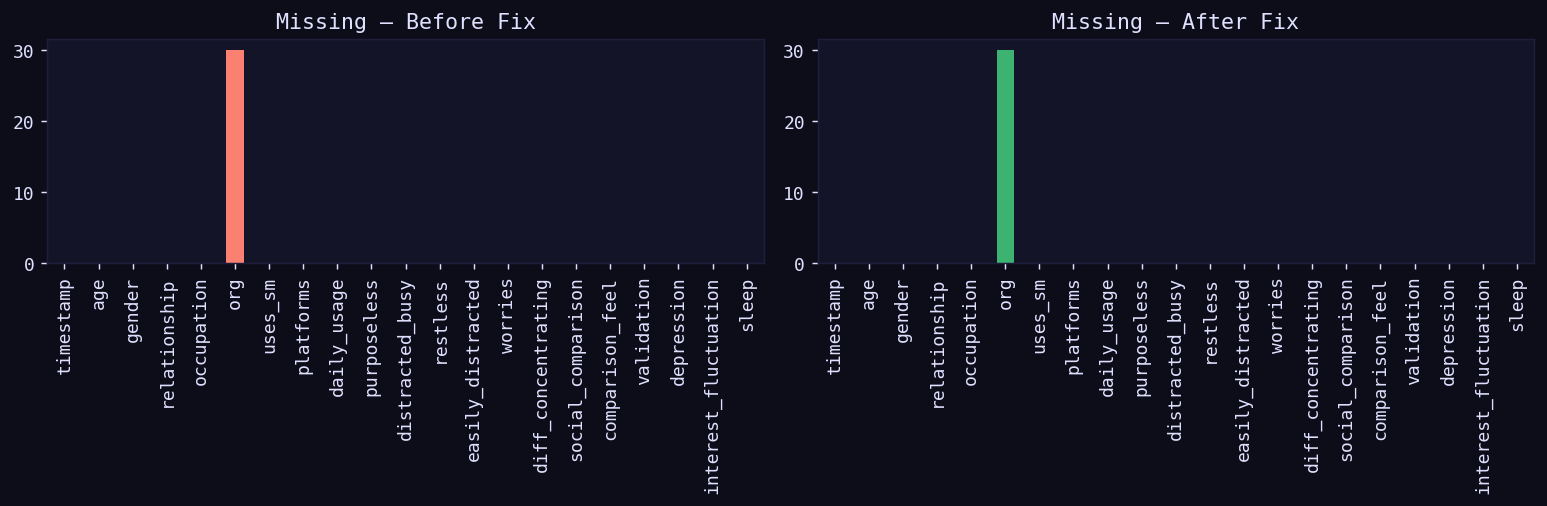

In [ ]:
# ══════════════════════════════════════════════
# STEP 3 — MISSING VALUES
# ══════════════════════════════════════════════
print("Missing values:\n", df.isnull().sum())

# Fix & clean
df = df[df["uses_sm"] == "Yes"].copy()
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df = df[df["age"].between(10, 80)].copy()

# Fill numeric NaNs with median
for col in df.select_dtypes("number").columns:
    df[col].fillna(df[col].median(), inplace=True)

print("\nAfter cleaning:", df.shape)
print("Missing values left:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.isnull().sum().plot(kind="bar", ax=axes[0], color="salmon", title="Missing — Before Fix")
df.isnull().sum().plot(kind="bar", ax=axes[1], color="mediumseagreen", title="Missing — After Fix")
plt.tight_layout()
plt.show()

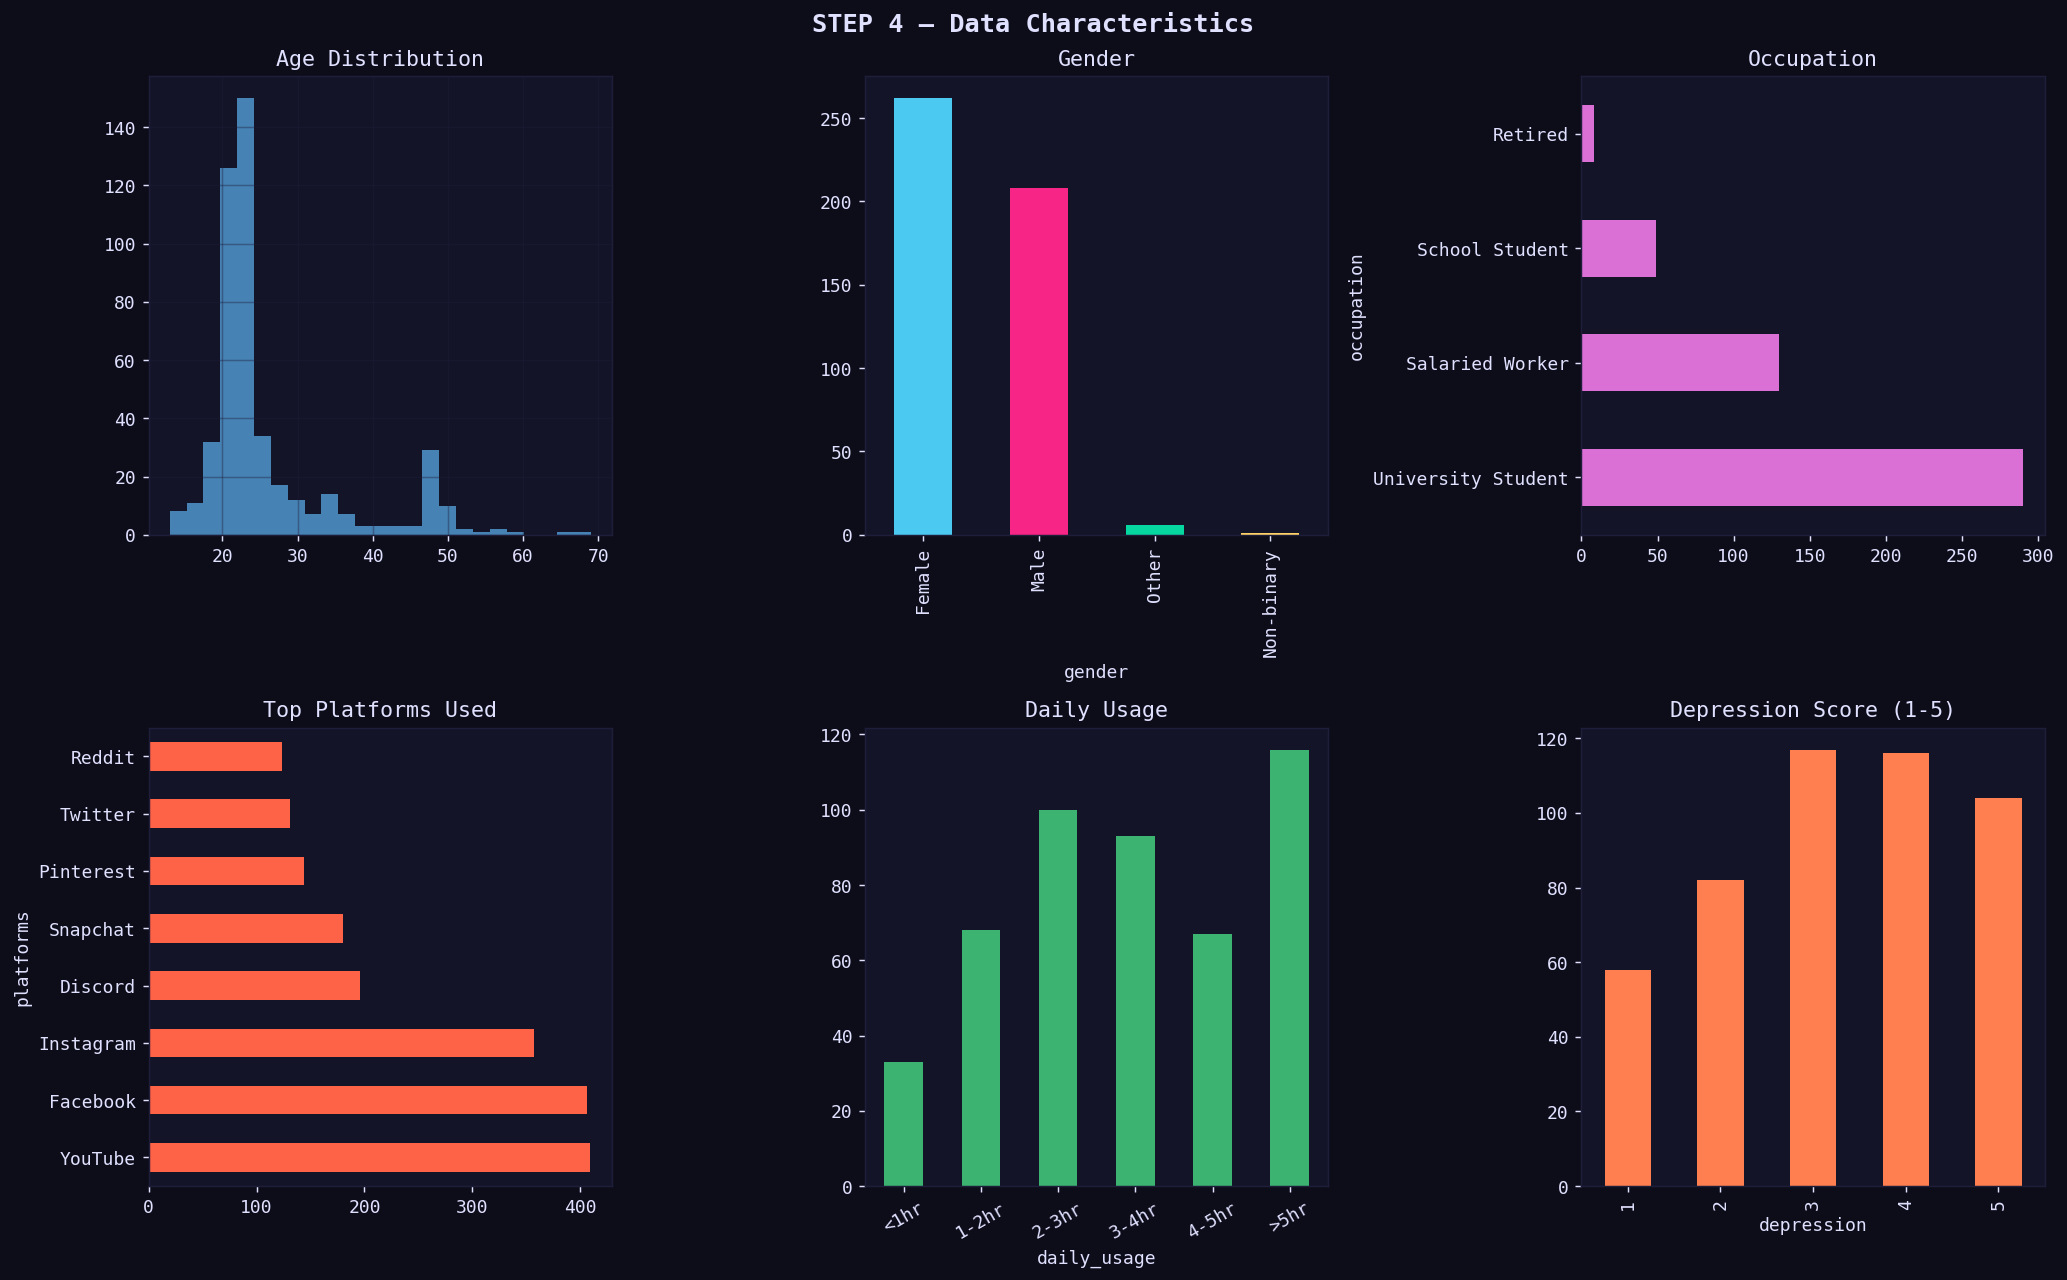

In [ ]:
# ══════════════════════════════════════════════
# STEP 4 — EXPLORE DATA CHARACTERISTICS
# ══════════════════════════════════════════════

# Clean gender & map usage to hours
df["gender"] = df["gender"].str.strip()
df["gender"] = df["gender"].where(df["gender"].isin(["Male","Female","Non-binary"]), "Other")

usage_map = {
    "Less than an Hour": 0.5, "Between 1 and 2 hours": 1.5,
    "Between 2 and 3 hours": 2.5, "Between 3 and 4 hours": 3.5,
    "Between 4 and 5 hours": 4.5, "More than 5 hours": 6.0
}
df["daily_hours"] = df["daily_usage"].map(usage_map)

# Platforms exploded
platform_counts = df["platforms"].dropna().str.split(",").explode().str.strip().value_counts().head(8)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("STEP 4 — Data Characteristics", fontsize=14, fontweight="bold")

df["age"].hist(bins=25, ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Age Distribution")

df["gender"].value_counts().plot(kind="bar", ax=axes[0,1], color=["#4CC9F0","#F72585","#06D6A0","#FFD166"])
axes[0,1].set_title("Gender")

df["occupation"].value_counts().plot(kind="barh", ax=axes[0,2], color="orchid")
axes[0,2].set_title("Occupation")

platform_counts.plot(kind="barh", ax=axes[1,0], color="tomato")
axes[1,0].set_title("Top Platforms Used")

df["daily_usage"].value_counts().reindex([
    "Less than an Hour","Between 1 and 2 hours","Between 2 and 3 hours",
    "Between 3 and 4 hours","Between 4 and 5 hours","More than 5 hours"
]).plot(kind="bar", ax=axes[1,1], color="mediumseagreen")
axes[1,1].set_title("Daily Usage")
axes[1,1].set_xticklabels(["<1hr","1-2hr","2-3hr","3-4hr","4-5hr",">5hr"], rotation=30)

df["depression"].value_counts().sort_index().plot(kind="bar", ax=axes[1,2], color="coral")
axes[1,2].set_title("Depression Score (1-5)")

plt.tight_layout()
plt.show()

MH Score stats:
 count    477.00
mean       3.14
std        0.89
min        1.00
25%        2.50
50%        3.20
75%        3.80
max        5.00
Name: mh_score, dtype: float64

Risk Levels:
 risk_level
High        191
Moderate    150
Severe       82
Low          54
Name: count, dtype: int64


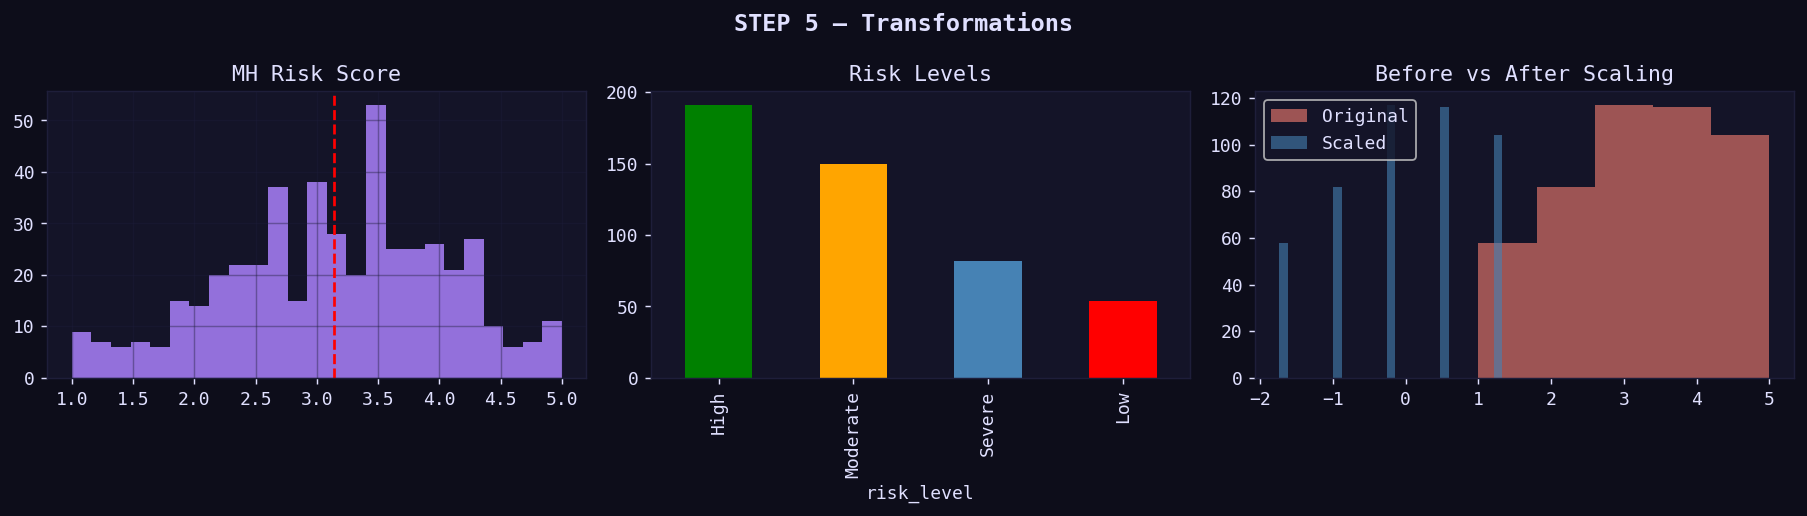

In [ ]:
# ══════════════════════════════════════════════
# STEP 5 — DATA TRANSFORMATIONS
# ══════════════════════════════════════════════

# Composite MH risk score
df["mh_score"] = (
    df["worries"]           * 0.20 +
    df["depression"]        * 0.25 +
    df["sleep"]             * 0.15 +
    df["easily_distracted"] * 0.10 +
    df["social_comparison"] * 0.15 +
    df["validation"]        * 0.15
).round(2)

df["risk_level"] = pd.cut(df["mh_score"],
    bins=[0, 2.0, 3.0, 4.0, 6.0],
    labels=["Low","Moderate","High","Severe"])

# Age groups
df["age_group"] = pd.cut(df["age"], bins=[10,18,24,30,40,80],
    labels=["<18","18-24","25-30","31-40","40+"])

# Encode & scale
le = LabelEncoder()
df["risk_enc"] = le.fit_transform(df["risk_level"].astype(str))

scale_cols = ["purposeless","distracted_busy","restless","easily_distracted",
              "worries","diff_concentrating","social_comparison",
              "validation","depression","interest_fluctuation","sleep"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[scale_cols])

print("MH Score stats:\n", df["mh_score"].describe().round(2))
print("\nRisk Levels:\n", df["risk_level"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("STEP 5 — Transformations", fontsize=13, fontweight="bold")

df["mh_score"].hist(bins=25, ax=axes[0], color="mediumpurple")
axes[0].axvline(df["mh_score"].mean(), color="red", linestyle="--")
axes[0].set_title("MH Risk Score")

df["risk_level"].value_counts().plot(kind="bar", ax=axes[1],
    color=["green","orange","steelblue","red"])
axes[1].set_title("Risk Levels")

axes[2].hist(df["depression"], bins=5, alpha=0.6, color="salmon", label="Original")
axes[2].hist(X_scaled[:, 8], bins=25, alpha=0.6, color="steelblue", label="Scaled")
axes[2].legend()
axes[2].set_title("Before vs After Scaling")

plt.tight_layout()
plt.show()

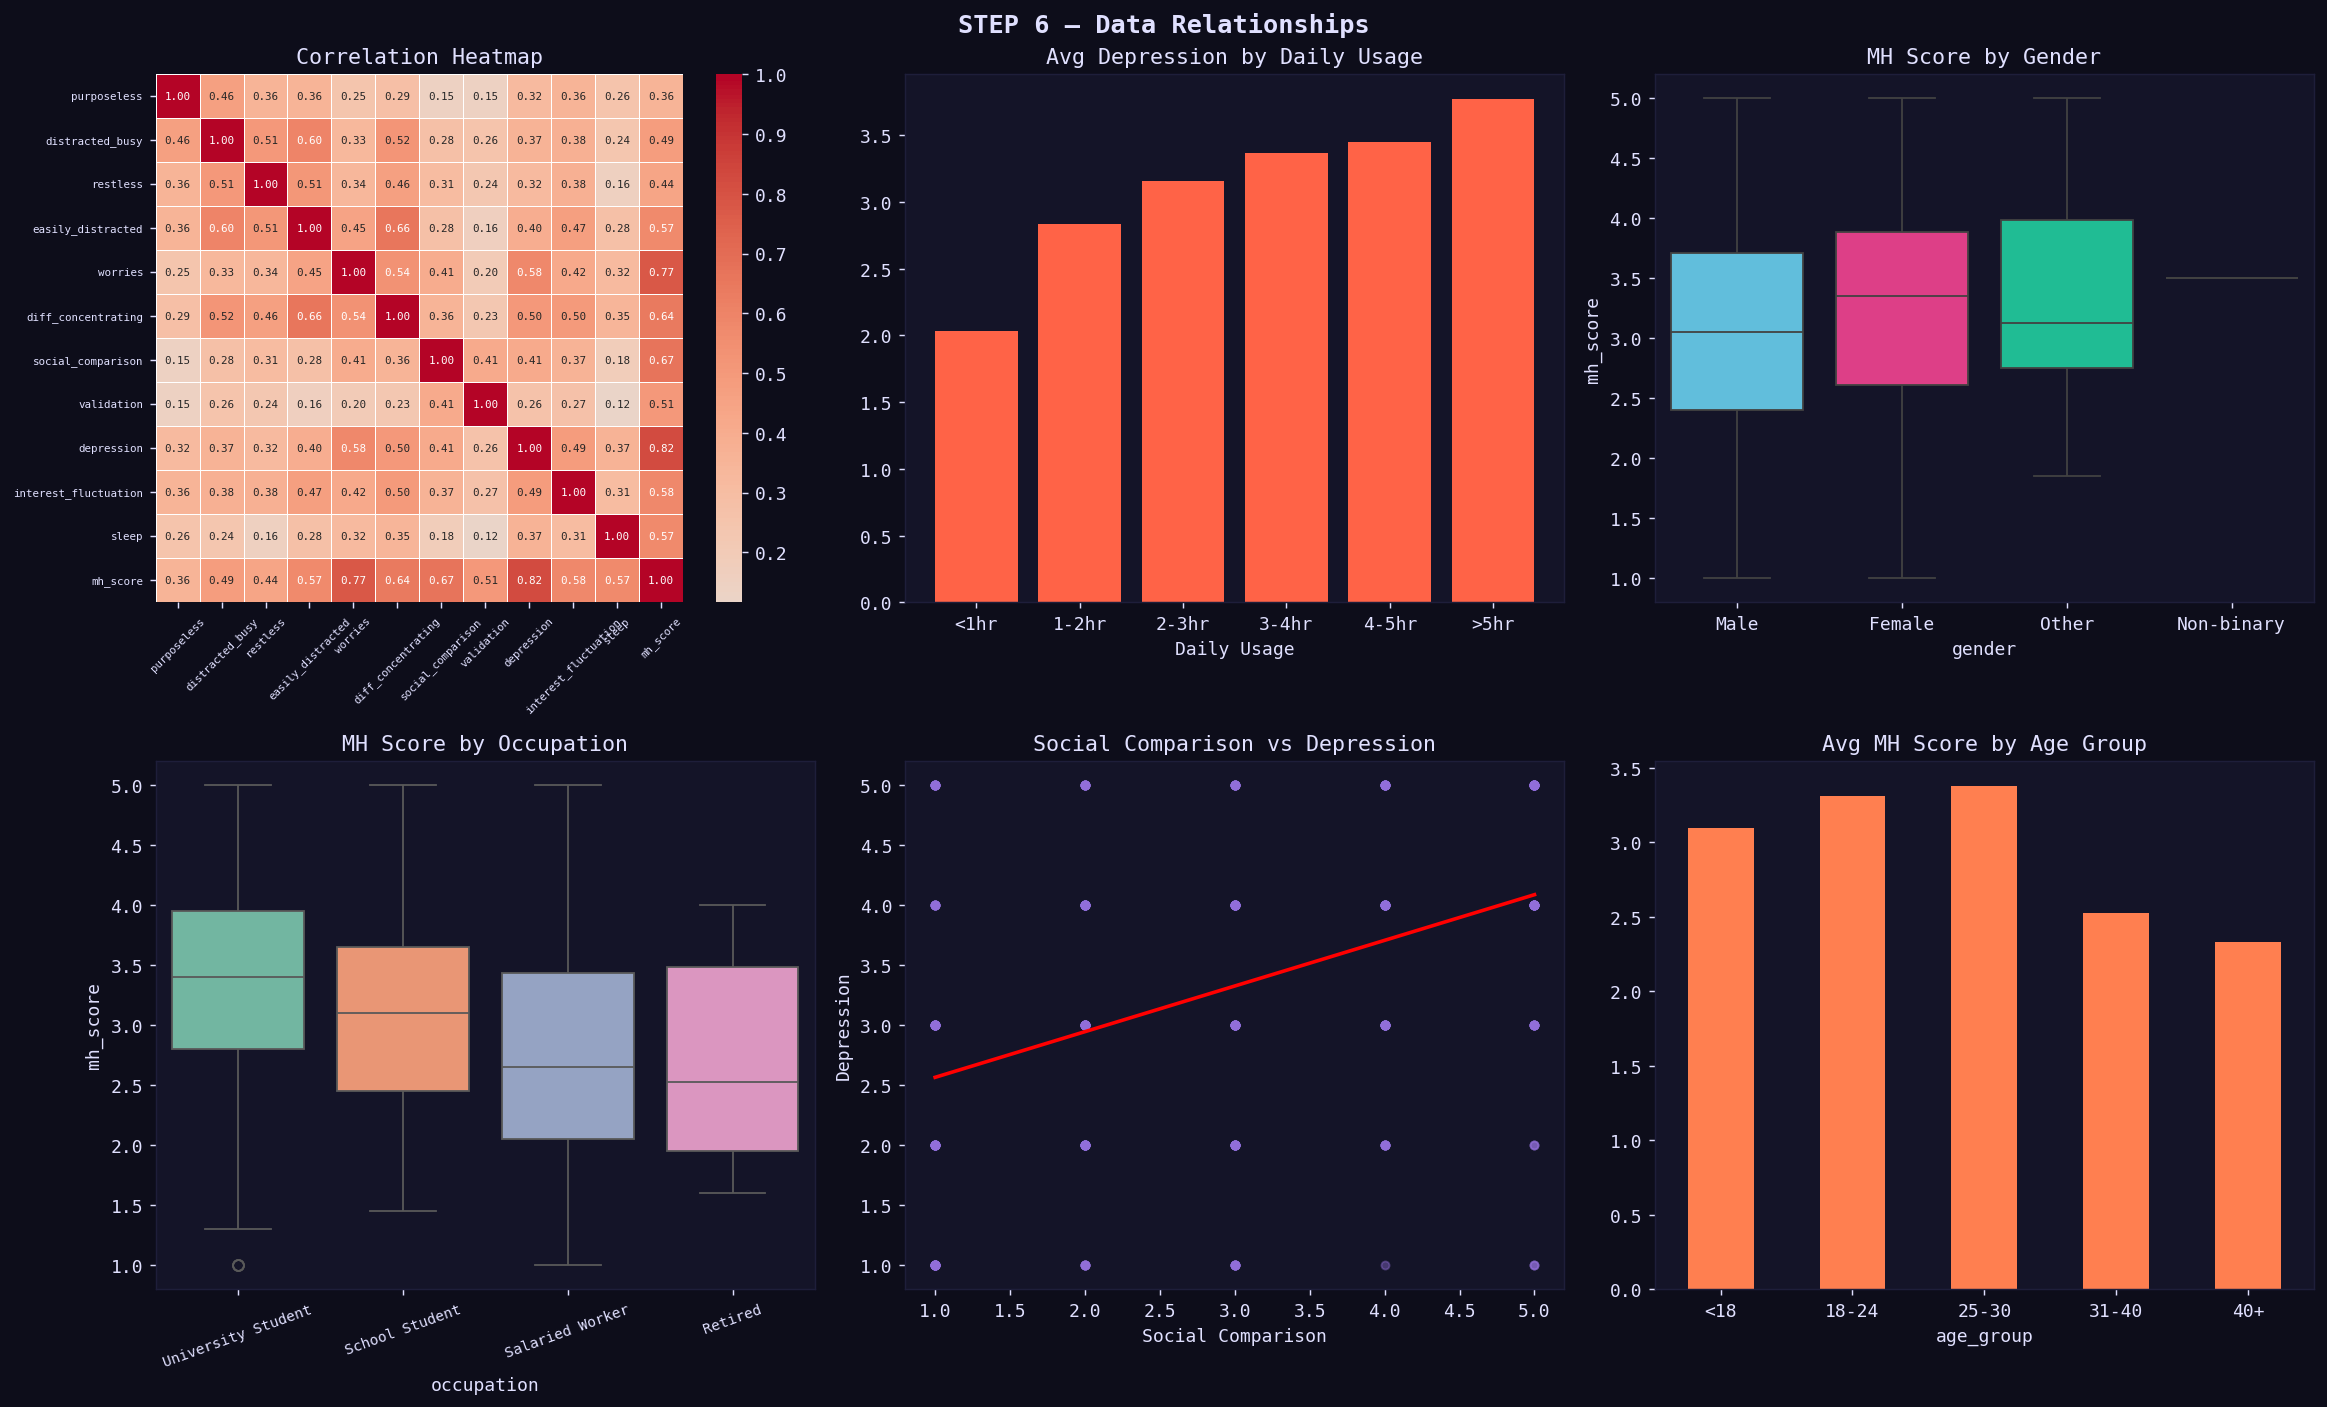

In [ ]:
# ══════════════════════════════════════════════
# STEP 6 — VISUALISE RELATIONSHIPS
# ══════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("STEP 6 — Data Relationships", fontsize=14, fontweight="bold")

# Correlation heatmap
corr = df[scale_cols + ["mh_score"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[0,0], annot_kws={"size":6}, linewidths=0.4)
axes[0,0].set_title("Correlation Heatmap")
axes[0,0].tick_params(axis="x", rotation=45, labelsize=6)
axes[0,0].tick_params(axis="y", labelsize=6)

# Usage vs depression
order = ["Less than an Hour","Between 1 and 2 hours","Between 2 and 3 hours",
         "Between 3 and 4 hours","Between 4 and 5 hours","More than 5 hours"]
avg_dep = df.groupby("daily_usage")["depression"].mean().reindex(order)
axes[0,1].bar(["<1hr","1-2hr","2-3hr","3-4hr","4-5hr",">5hr"], avg_dep.values, color="tomato")
axes[0,1].set_title("Avg Depression by Daily Usage")
axes[0,1].set_xlabel("Daily Usage")

# MH score by gender
sns.boxplot(data=df, x="gender", y="mh_score", ax=axes[0,2],
            palette=["#4CC9F0","#F72585","#06D6A0","#FFD166"])
axes[0,2].set_title("MH Score by Gender")

# MH score by occupation
sns.boxplot(data=df, x="occupation", y="mh_score", ax=axes[1,0],
            palette="Set2")
axes[1,0].set_title("MH Score by Occupation")
axes[1,0].tick_params(axis="x", rotation=20, labelsize=8)

# Social comparison vs depression
axes[1,1].scatter(df["social_comparison"], df["depression"],
                  alpha=0.4, color="mediumpurple", s=20)
m, b = np.polyfit(df["social_comparison"], df["depression"], 1)
axes[1,1].plot([1,5], [m*1+b, m*5+b], color="red", lw=2)
axes[1,1].set_title("Social Comparison vs Depression")
axes[1,1].set_xlabel("Social Comparison")
axes[1,1].set_ylabel("Depression")

# MH score by age group
df.groupby("age_group", observed=True)["mh_score"].mean().plot(
    kind="bar", ax=axes[1,2], color="coral")
axes[1,2].set_title("Avg MH Score by Age Group")
axes[1,2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Outlier count (IQR method):
  age: 82 outliers
  daily_hours: 0 outliers
  mh_score: 0 outliers
  depression: 0 outliers
  sleep: 0 outliers
  social_comparison: 0 outliers

Isolation Forest flagged: 24 rows


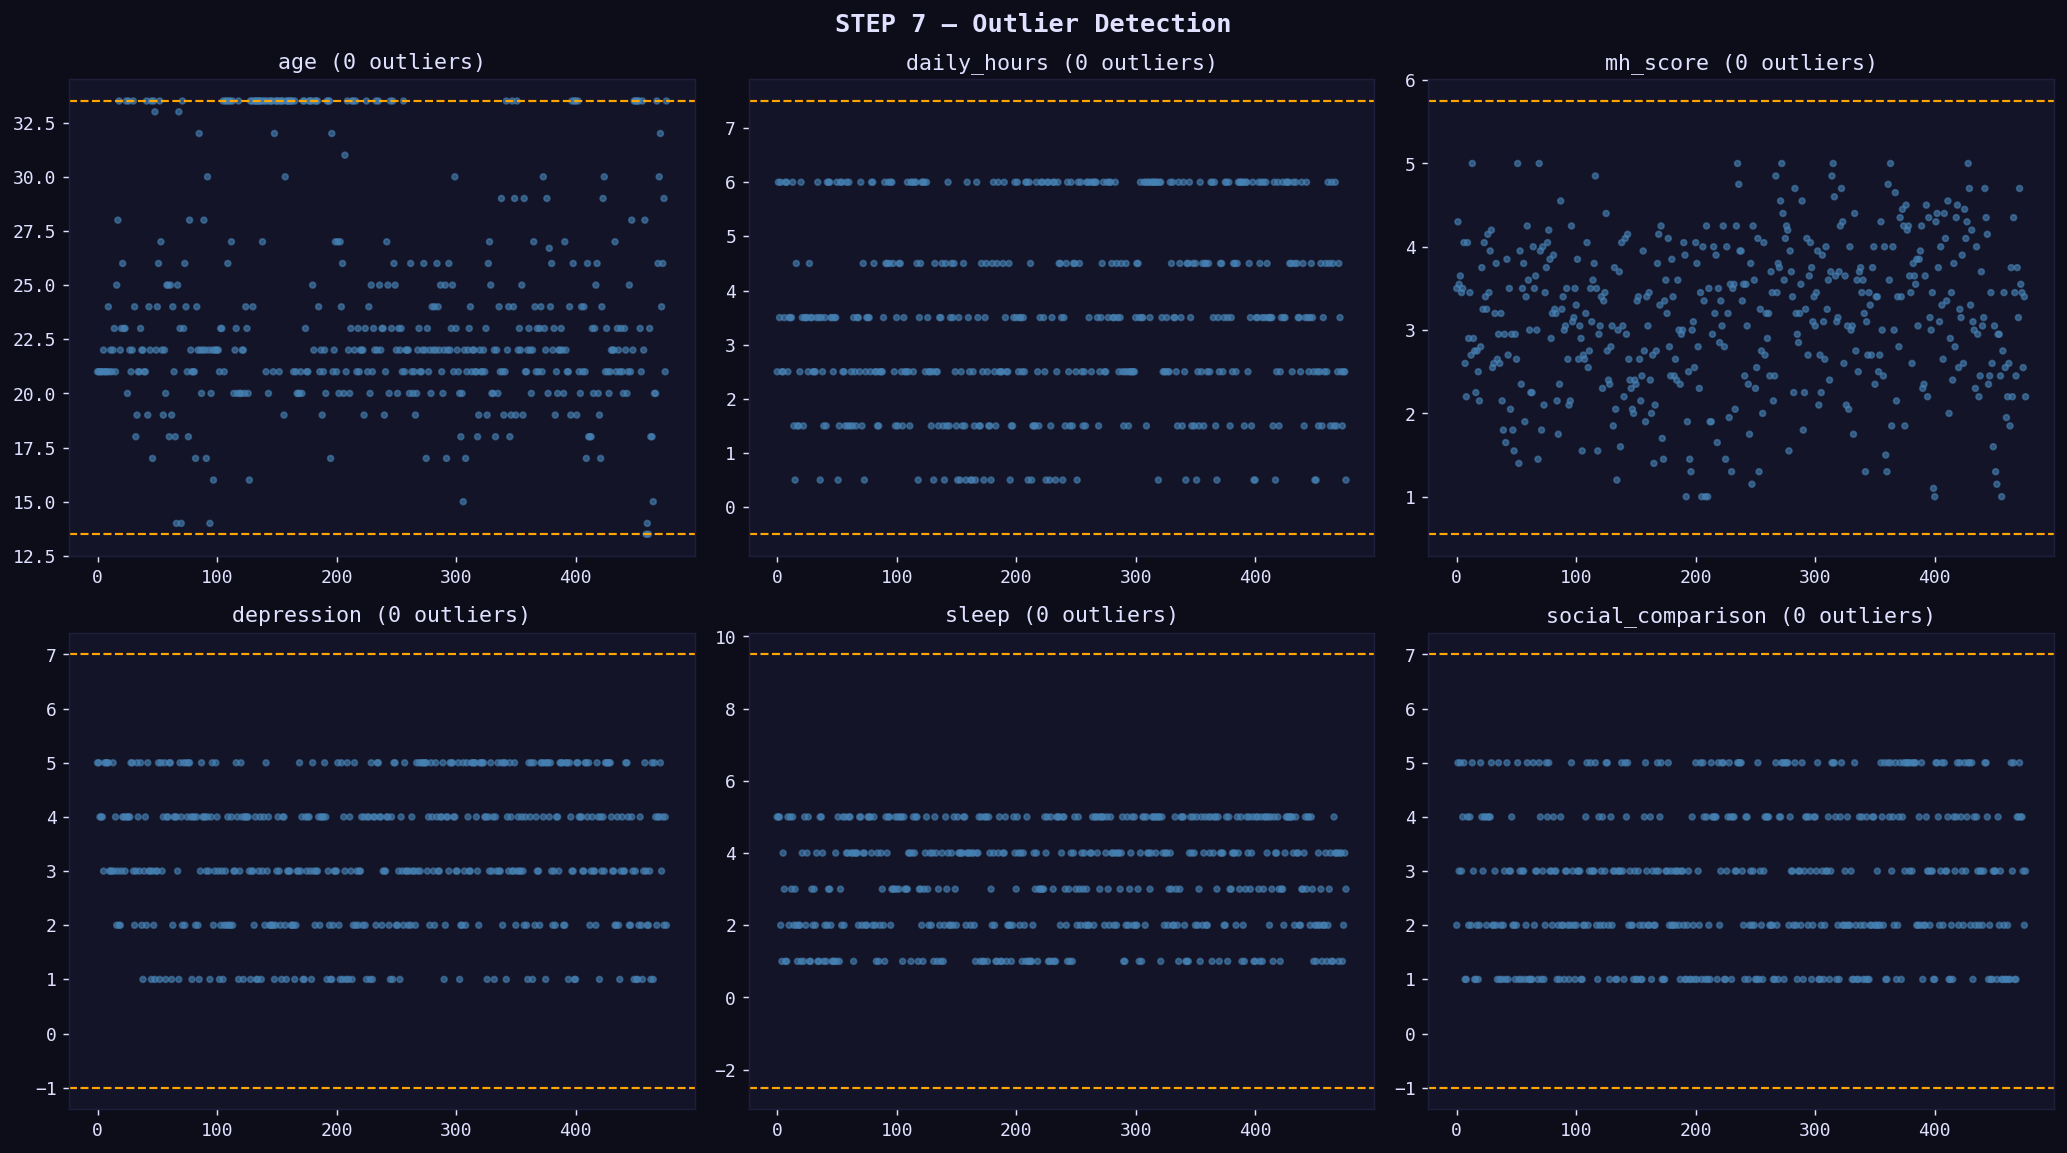

In [ ]:
# ══════════════════════════════════════════════
# STEP 7 — DETECT & MANAGE OUTLIERS
# ══════════════════════════════════════════════

detect_cols = ["age","daily_hours","mh_score","depression","sleep","social_comparison"]

print("Outlier count (IQR method):")
for col in detect_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    print(f"  {col}: {n} outliers")

# Cap outliers
for col in ["age","daily_hours","mh_score"]:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1-1.5*IQR, Q3+1.5*IQR)

# Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
df["outlier"] = iso.fit_predict(df[scale_cols].fillna(df[scale_cols].median()))
print(f"\nIsolation Forest flagged: {(df['outlier']==-1).sum()} rows")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("STEP 7 — Outlier Detection", fontsize=14, fontweight="bold")

for ax, col in zip(axes.flat, detect_cols):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    is_out = (df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)
    ax.scatter(range(len(df)), df[col],
               c=["red" if o else "steelblue" for o in is_out], s=10, alpha=0.6)
    ax.axhline(Q3+1.5*IQR, color="orange", linestyle="--", lw=1.2)
    ax.axhline(Q1-1.5*IQR, color="orange", linestyle="--", lw=1.2)
    ax.set_title(f"{col} ({is_out.sum()} outliers)")

plt.tight_layout()
plt.show()

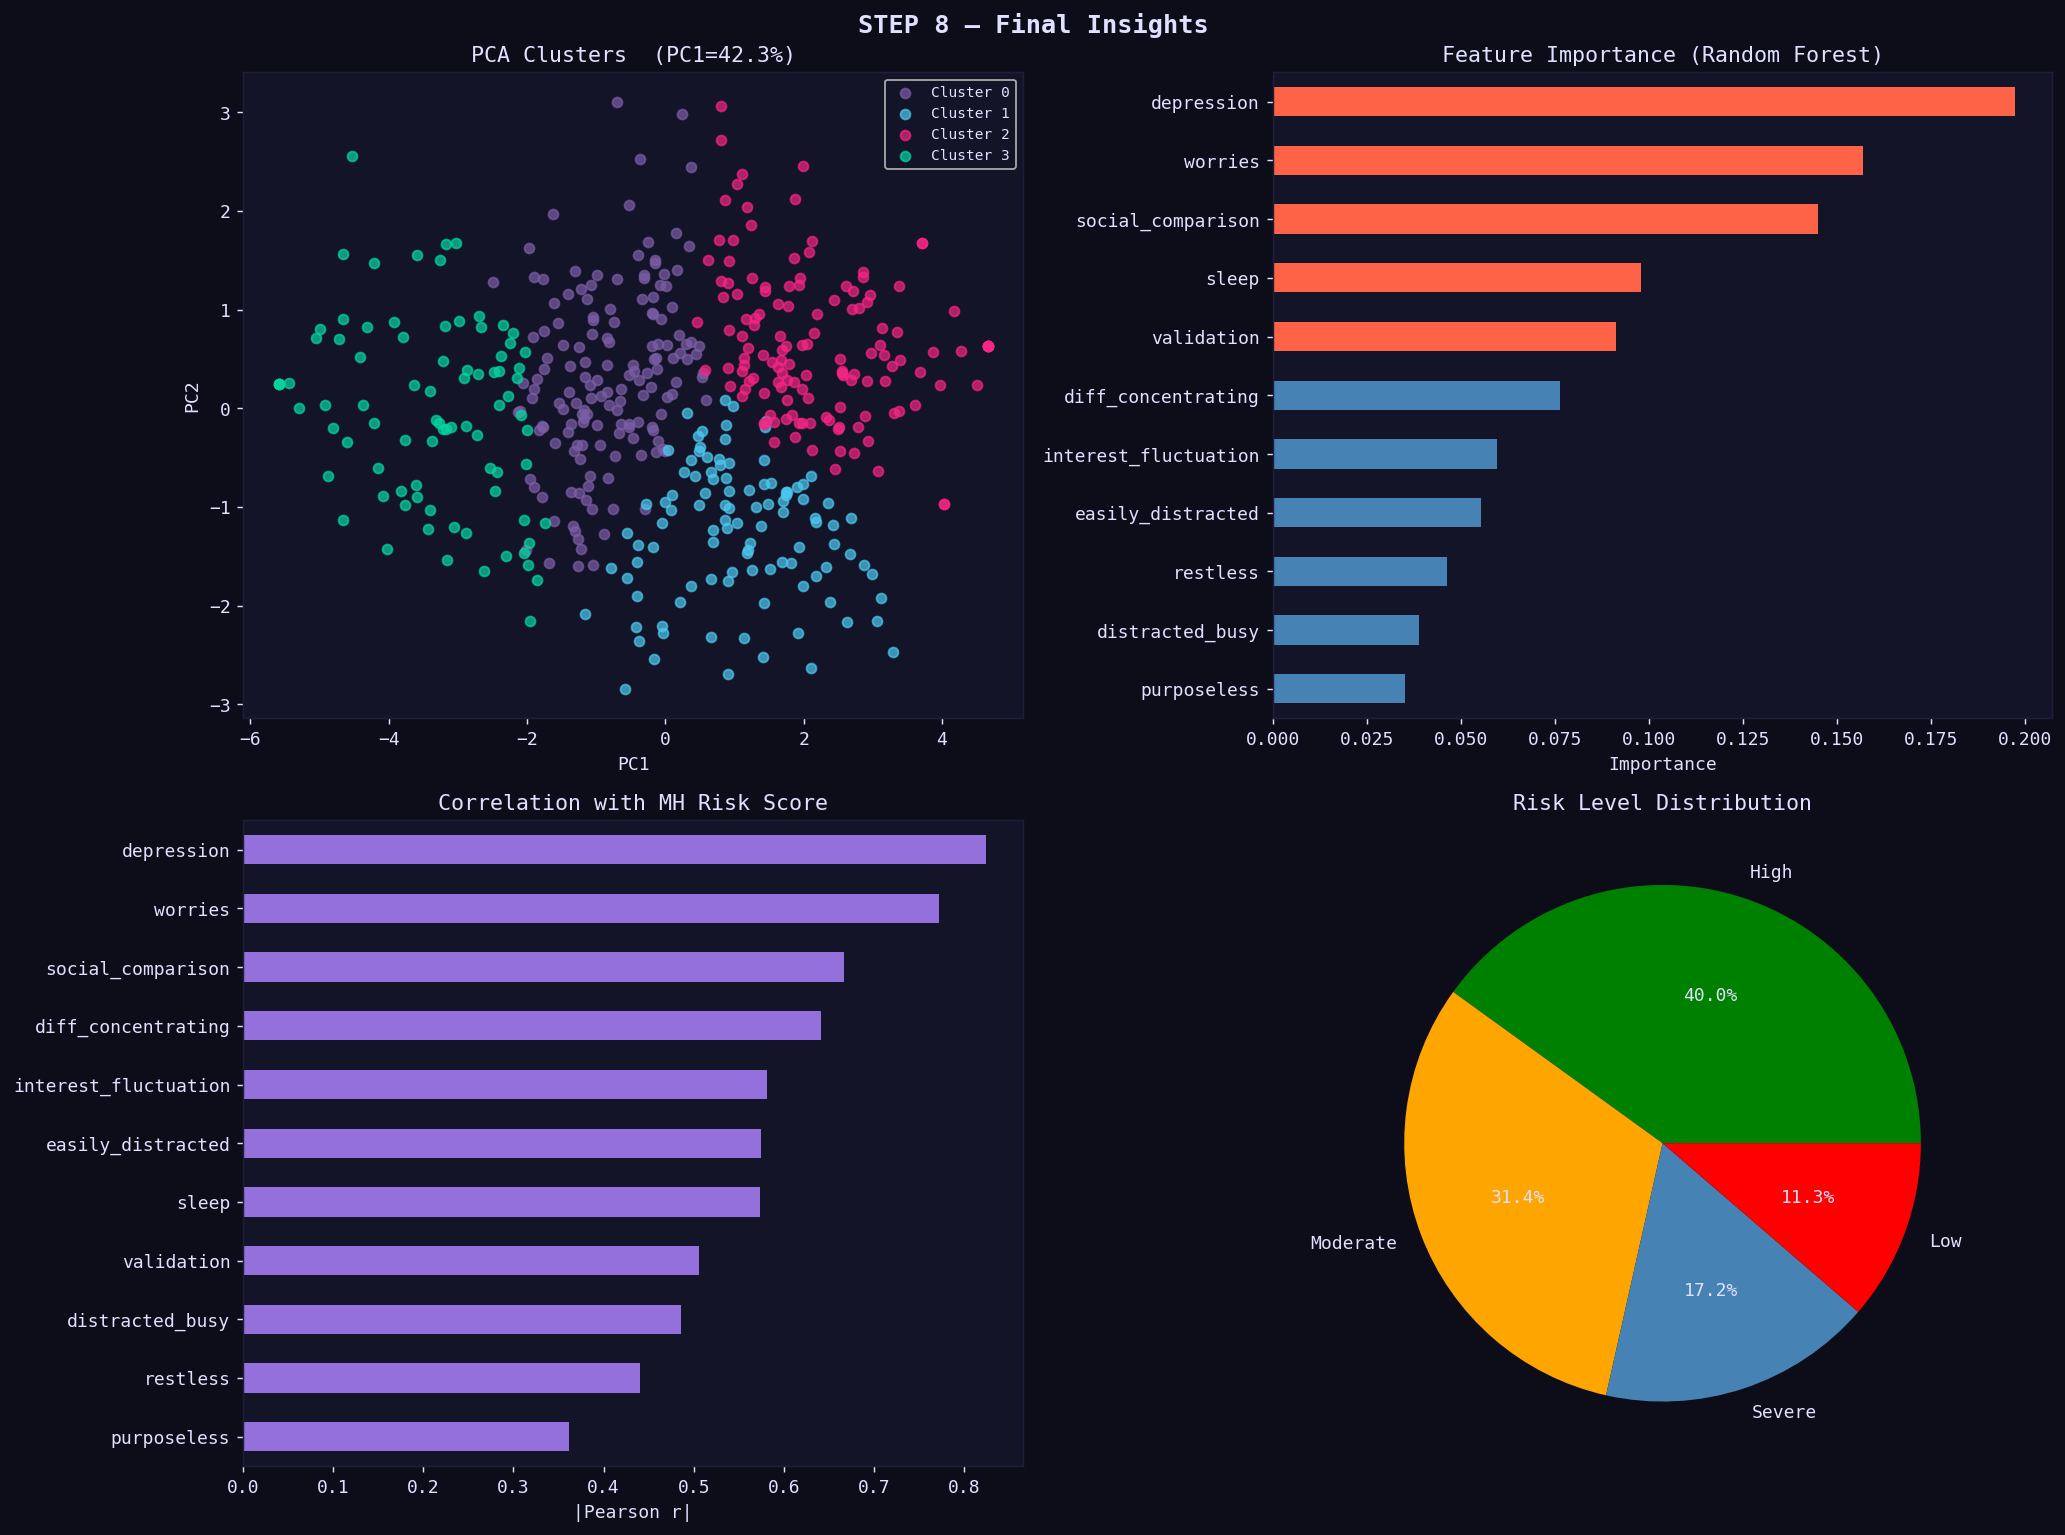


📌 KEY INSIGHTS
----------------------------------------
  depression: r=0.82
  worries: r=0.77
  social_comparison: r=0.67
  diff_concentrating: r=0.64
  interest_fluctuation: r=0.58

Highest risk occupation : University Student
Highest risk age group  : 25-30
Avg daily usage         : 3.5 hrs
Most used platform      : YouTube


In [ ]:
# ══════════════════════════════════════════════
# STEP 8 — KEY INSIGHTS & FINAL VISUALIZATIONS
# ══════════════════════════════════════════════

# PCA + KMeans
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Random Forest feature importance
rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_scaled, df["risk_enc"])
feat_imp = pd.Series(rf.feature_importances_, index=scale_cols).sort_values()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("STEP 8 — Final Insights", fontsize=14, fontweight="bold")

# PCA cluster plot
colors = ["#7B5EA7","#4CC9F0","#F72585","#06D6A0"]
for c in range(4):
    mask = clusters == c
    axes[0,0].scatter(X_pca[mask,0], X_pca[mask,1],
                      c=colors[c], label=f"Cluster {c}", s=30, alpha=0.7)
axes[0,0].set_title(f"PCA Clusters  (PC1={pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0,0].legend(fontsize=8)
axes[0,0].set_xlabel("PC1")
axes[0,0].set_ylabel("PC2")

# Feature importance
feat_imp.plot(kind="barh", ax=axes[0,1],
              color=["tomato" if v > feat_imp.median() else "steelblue" for v in feat_imp])
axes[0,1].set_title("Feature Importance (Random Forest)")
axes[0,1].set_xlabel("Importance")

# Top correlates with mh_score
top_corr = df[scale_cols + ["mh_score"]].corr()["mh_score"].drop("mh_score").abs().sort_values()
top_corr.plot(kind="barh", ax=axes[1,0], color="mediumpurple")
axes[1,0].set_title("Correlation with MH Risk Score")
axes[1,0].set_xlabel("|Pearson r|")

# Risk level pie
df["risk_level"].value_counts().plot(
    kind="pie", ax=axes[1,1], autopct="%1.1f%%",
    colors=["green","orange","steelblue","red"],
    textprops={"fontsize": 10})
axes[1,1].set_title("Risk Level Distribution")
axes[1,1].set_ylabel("")

plt.tight_layout()
plt.show()

# Final summary
print("\n📌 KEY INSIGHTS")
print("-" * 40)
top5 = df[scale_cols + ["mh_score"]].corr()["mh_score"].drop("mh_score").abs().sort_values(ascending=False).head(5)
for f, v in top5.items():
    print(f"  {f}: r={v:.2f}")
print(f"\nHighest risk occupation : {df.groupby('occupation')['mh_score'].mean().idxmax()}")
print(f"Highest risk age group  : {df.groupby('age_group', observed=True)['mh_score'].mean().idxmax()}")
print(f"Avg daily usage         : {df['daily_hours'].mean():.1f} hrs")
print(f"Most used platform      : {df['platforms'].dropna().str.split(',').explode().str.strip().value_counts().index[0]}")

Sentiment Distribution:
sentiment_label
Neutral          217
Negative         103
Very Negative     64
Positive          60
Very Positive     33
Name: count, dtype: int64

3-Class:
sentiment_3
Neutral     217
Negative    167
Positive     93
Name: count, dtype: int64

Overall mood → 😞 Negative
Avg polarity : -0.110


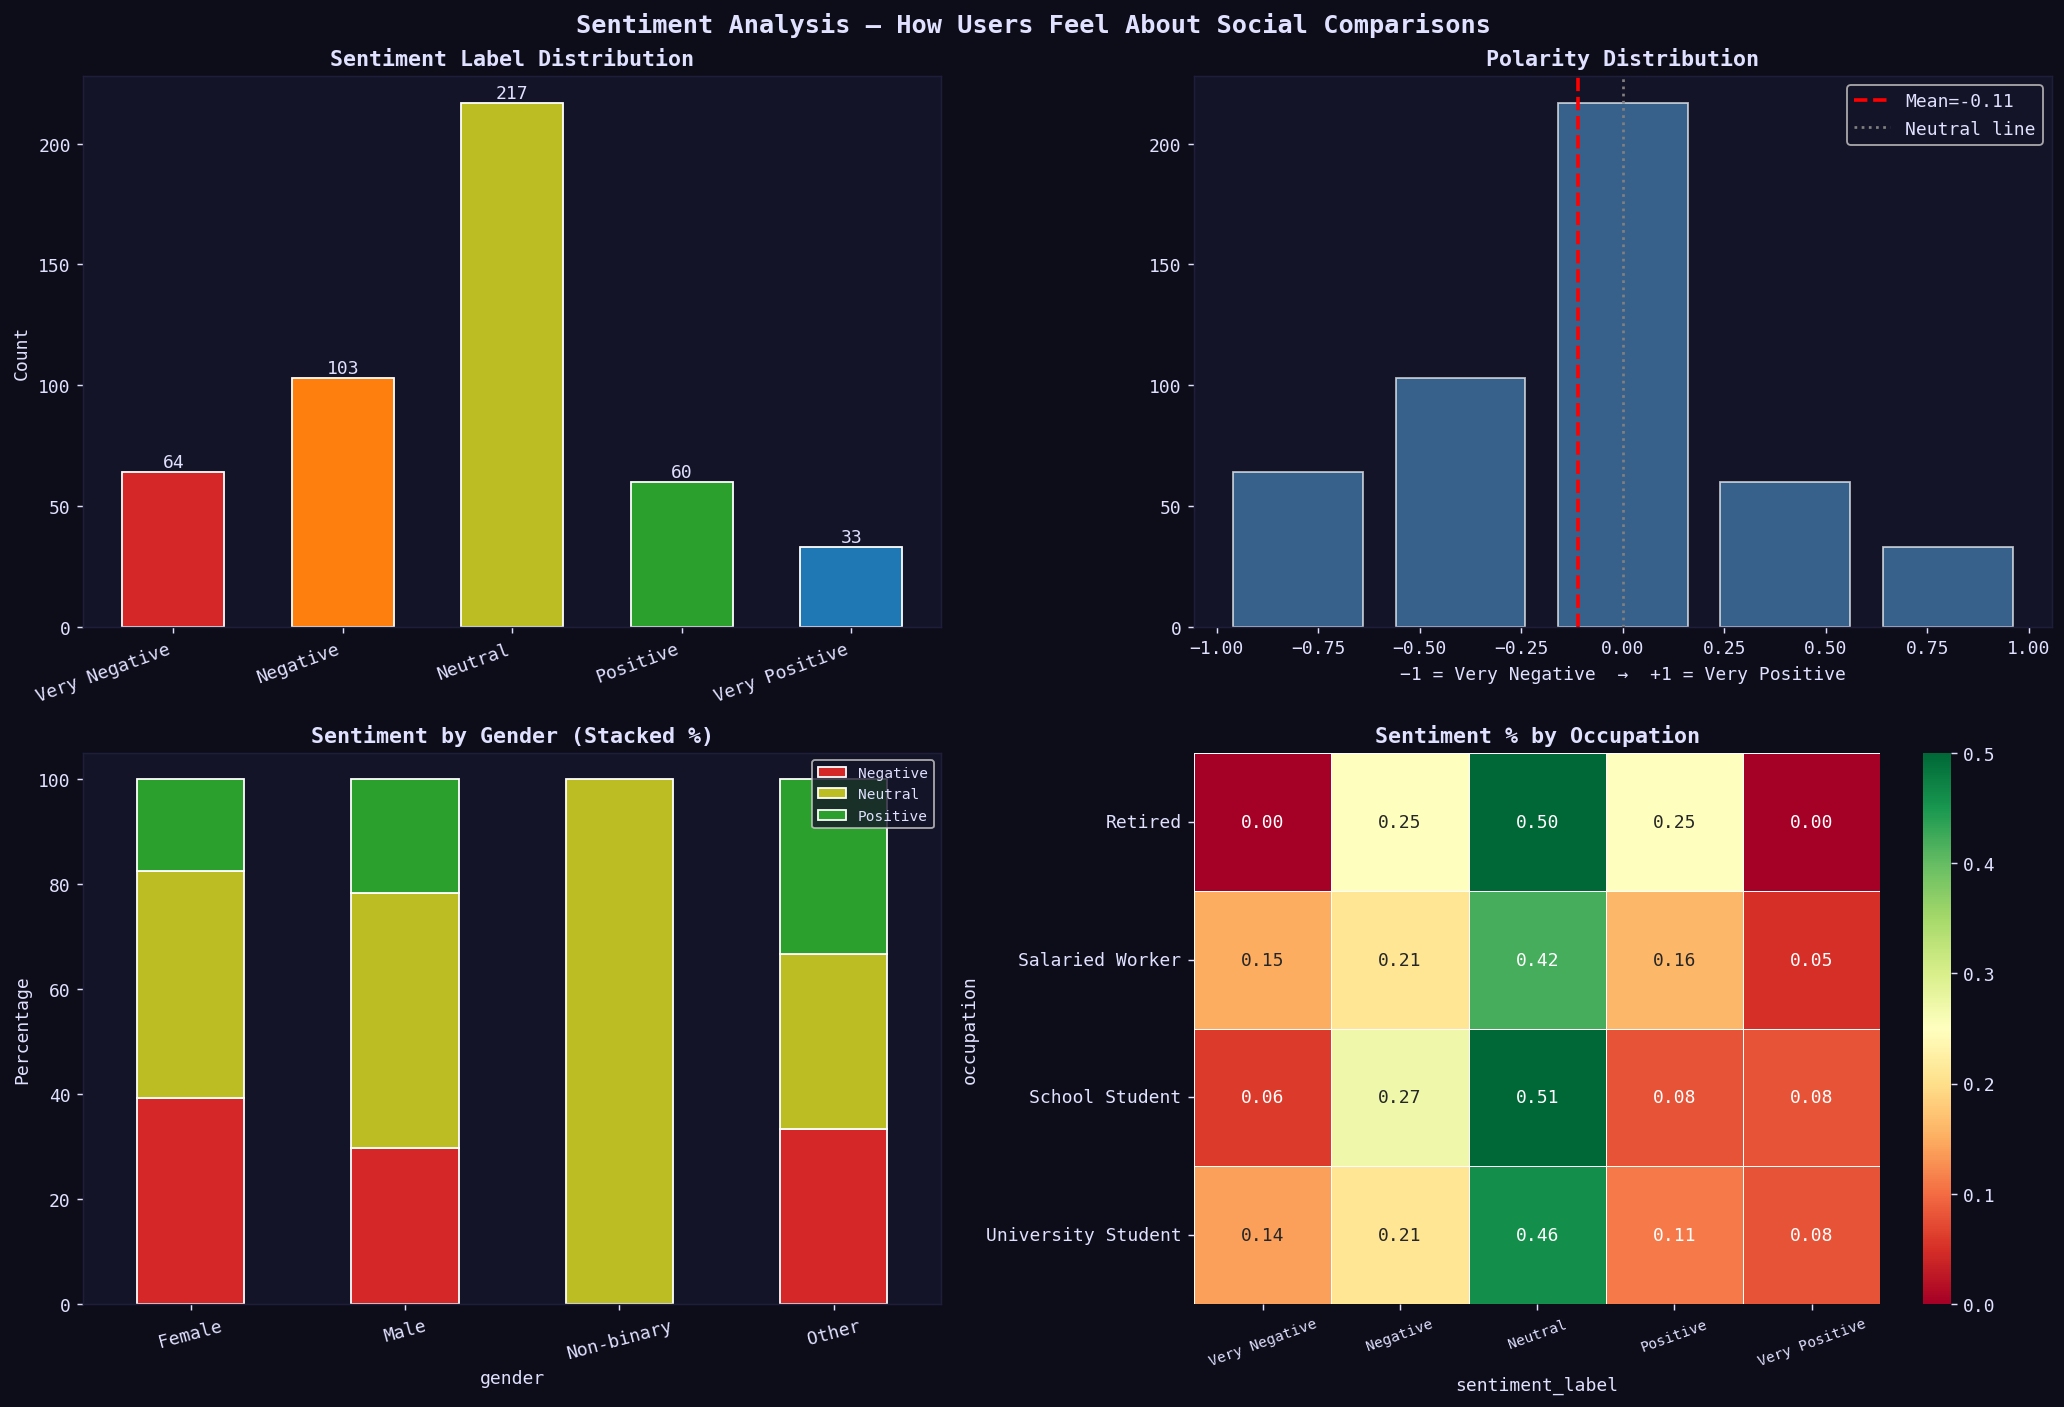

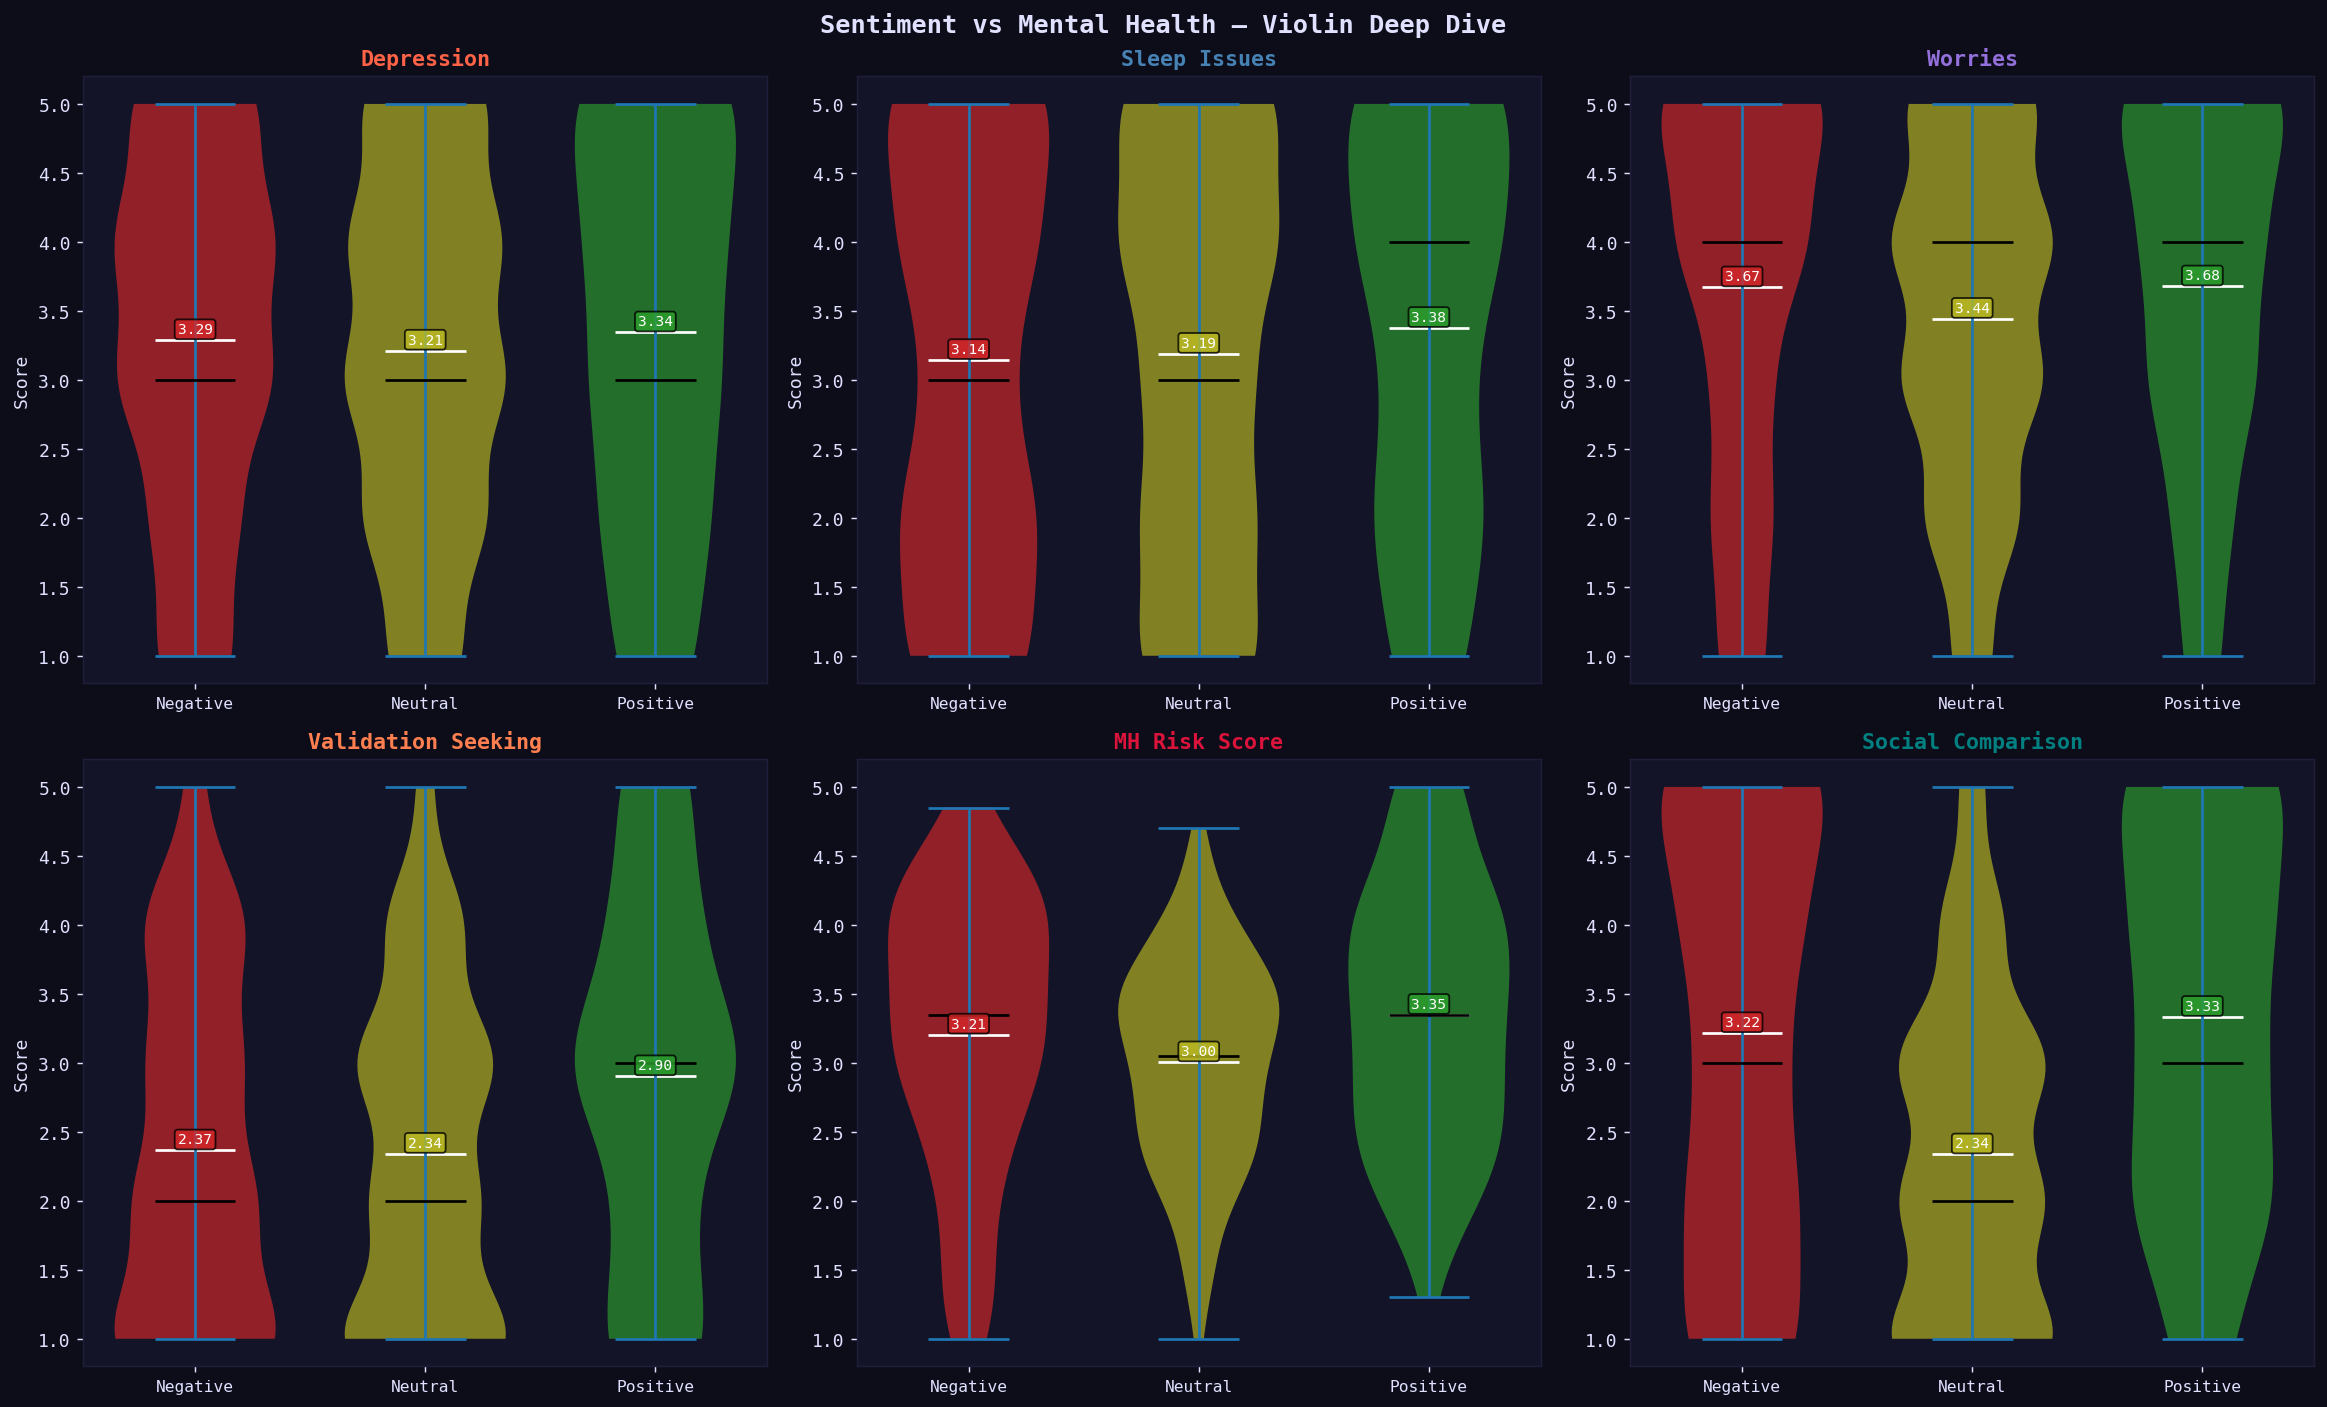

KRUSKAL-WALLIS TEST  (Negative vs Neutral vs Positive)
Feature                      H-stat   p-value   Sig?
-------------------------------------------------------
depression                     0.94   0.6246    ❌ No
sleep                          1.52   0.4672    ❌ No
worries                        5.99   0.0501    ❌ No
mh_score                      11.57   0.0031    ✅ YES
validation                    13.08   0.0014    ✅ YES
social_comparison             48.61   0.0000    ✅ YES

SPEARMAN CORRELATION  (polarity vs MH features)
Feature                      rho       p-value
-------------------------------------------------------
depression                   +0.019    0.6755   ❌
sleep                        +0.055    0.2298   ❌
worries                      -0.018    0.6902   ❌
mh_score                     +0.001    0.9900   ❌
validation                   +0.133    0.0036   ✅
social_comparison            -0.036    0.4308   ❌

CHI-SQUARE  (Sentiment ↔ Risk Level)
chi2=27.29  dof=6  p=0.00

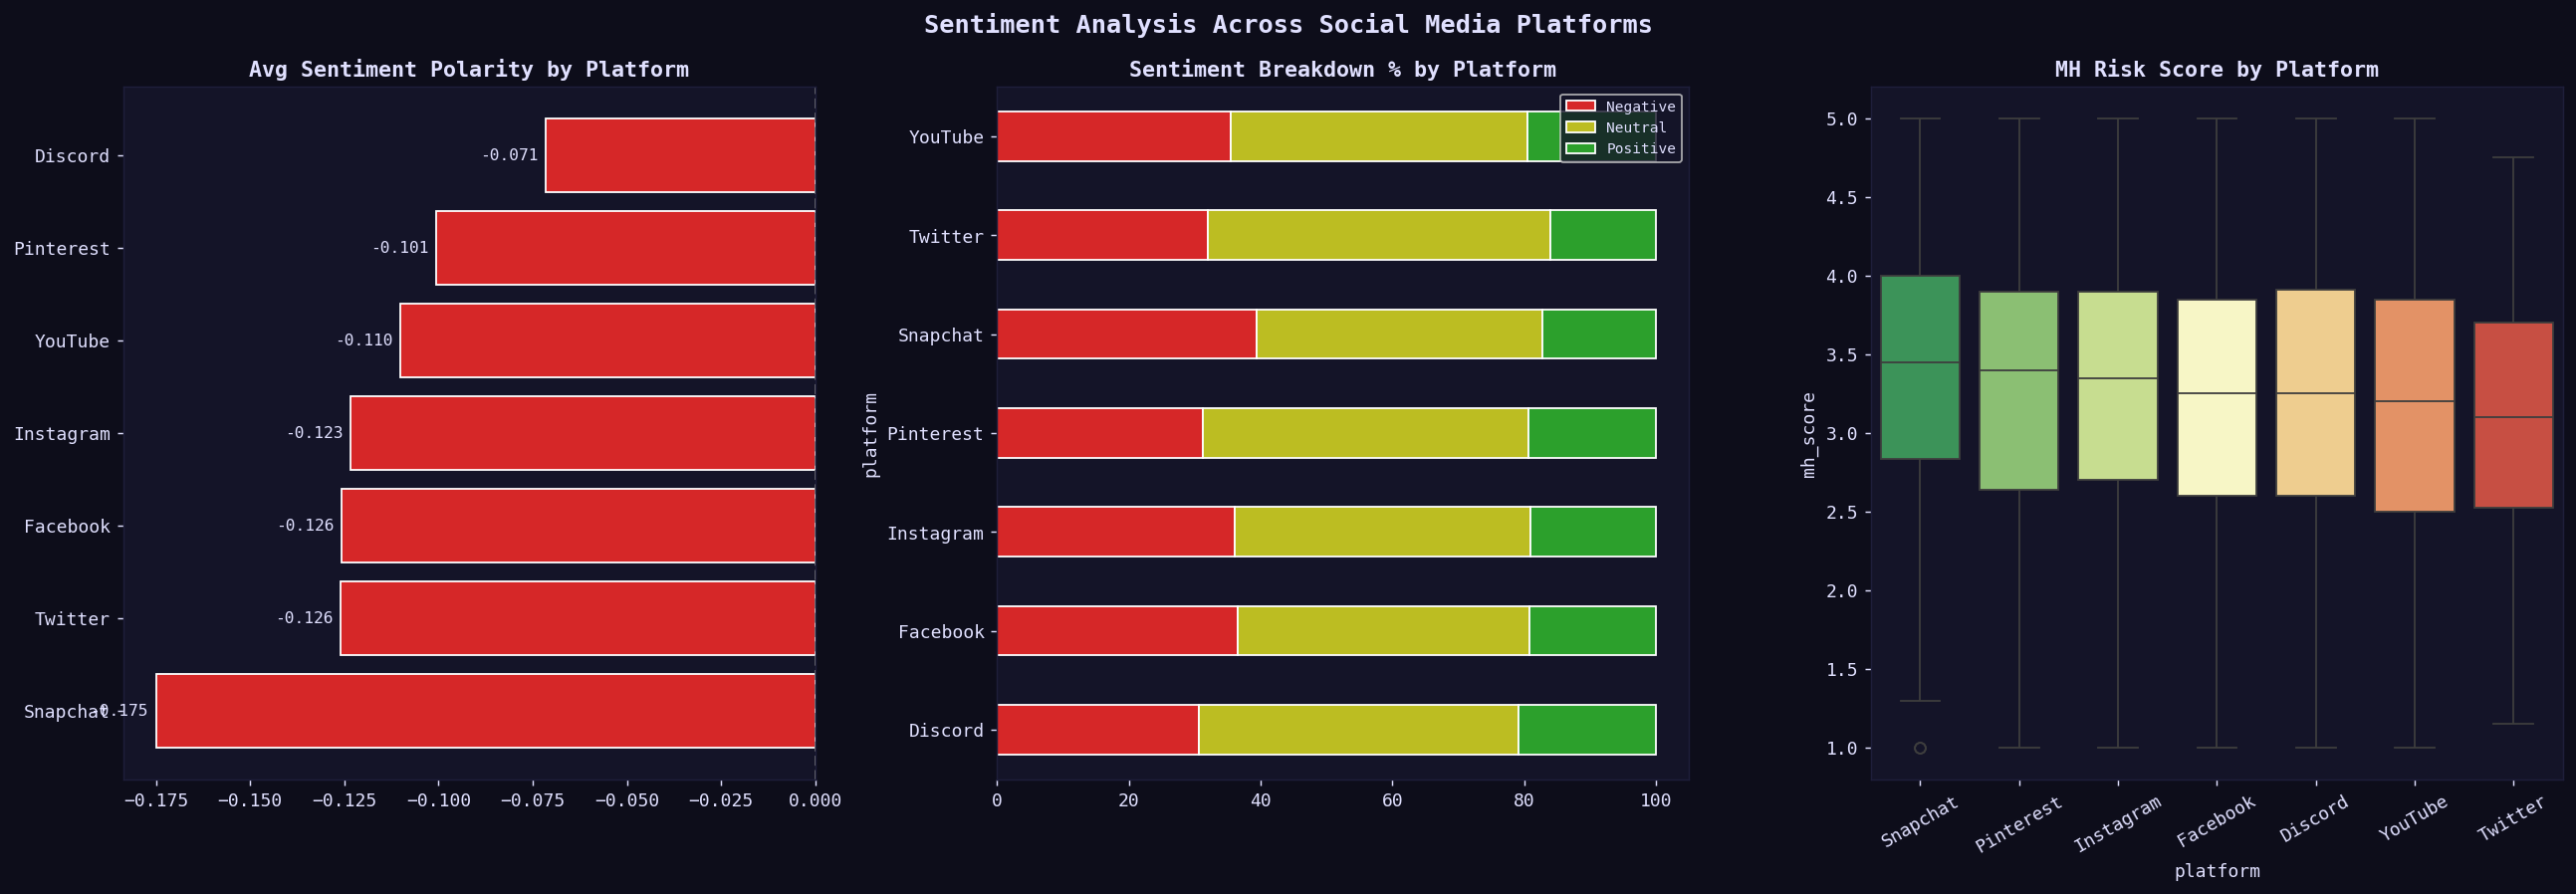

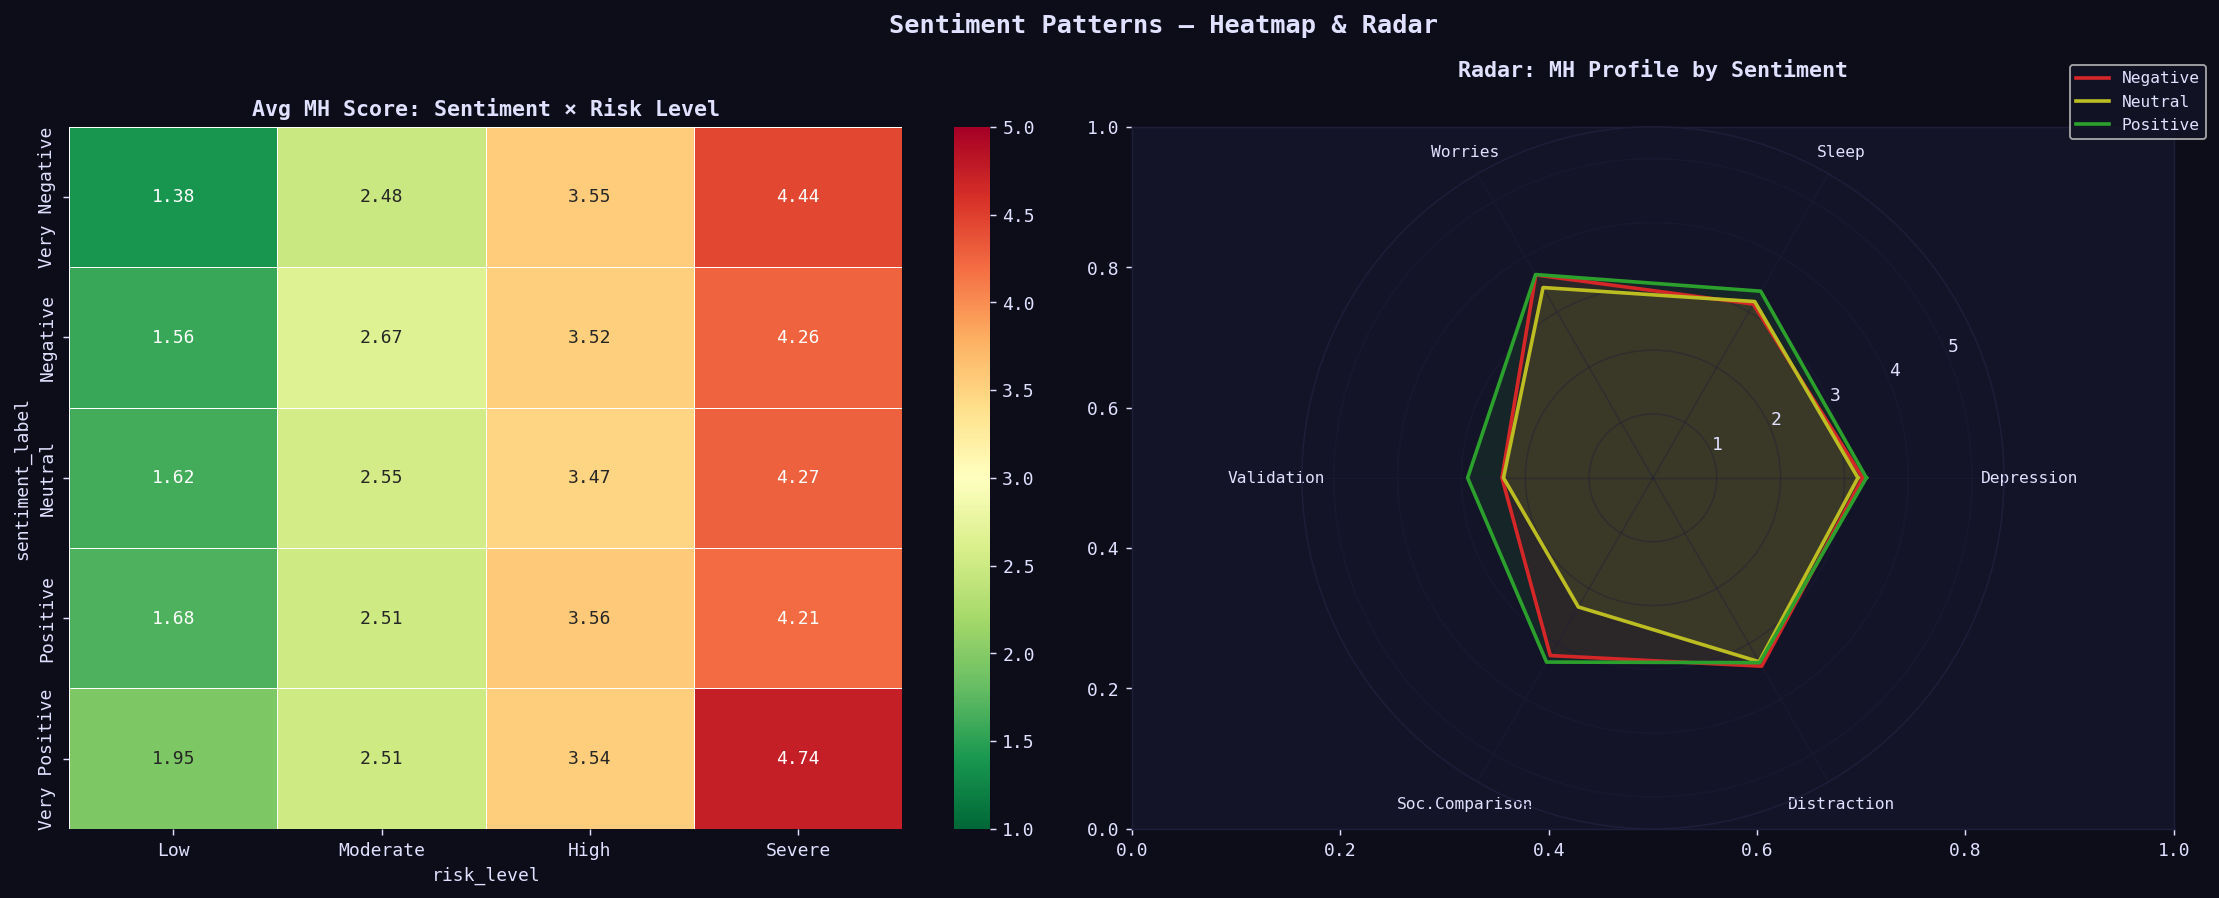

5-Fold CV F1 (macro): 0.456 ± 0.082

              precision    recall  f1-score   support

    Negative       0.47      0.38      0.42       167
     Neutral       0.60      0.57      0.58       217
    Positive       0.34      0.51      0.41        93

    accuracy                           0.49       477
   macro avg       0.47      0.48      0.47       477
weighted avg       0.50      0.49      0.49       477



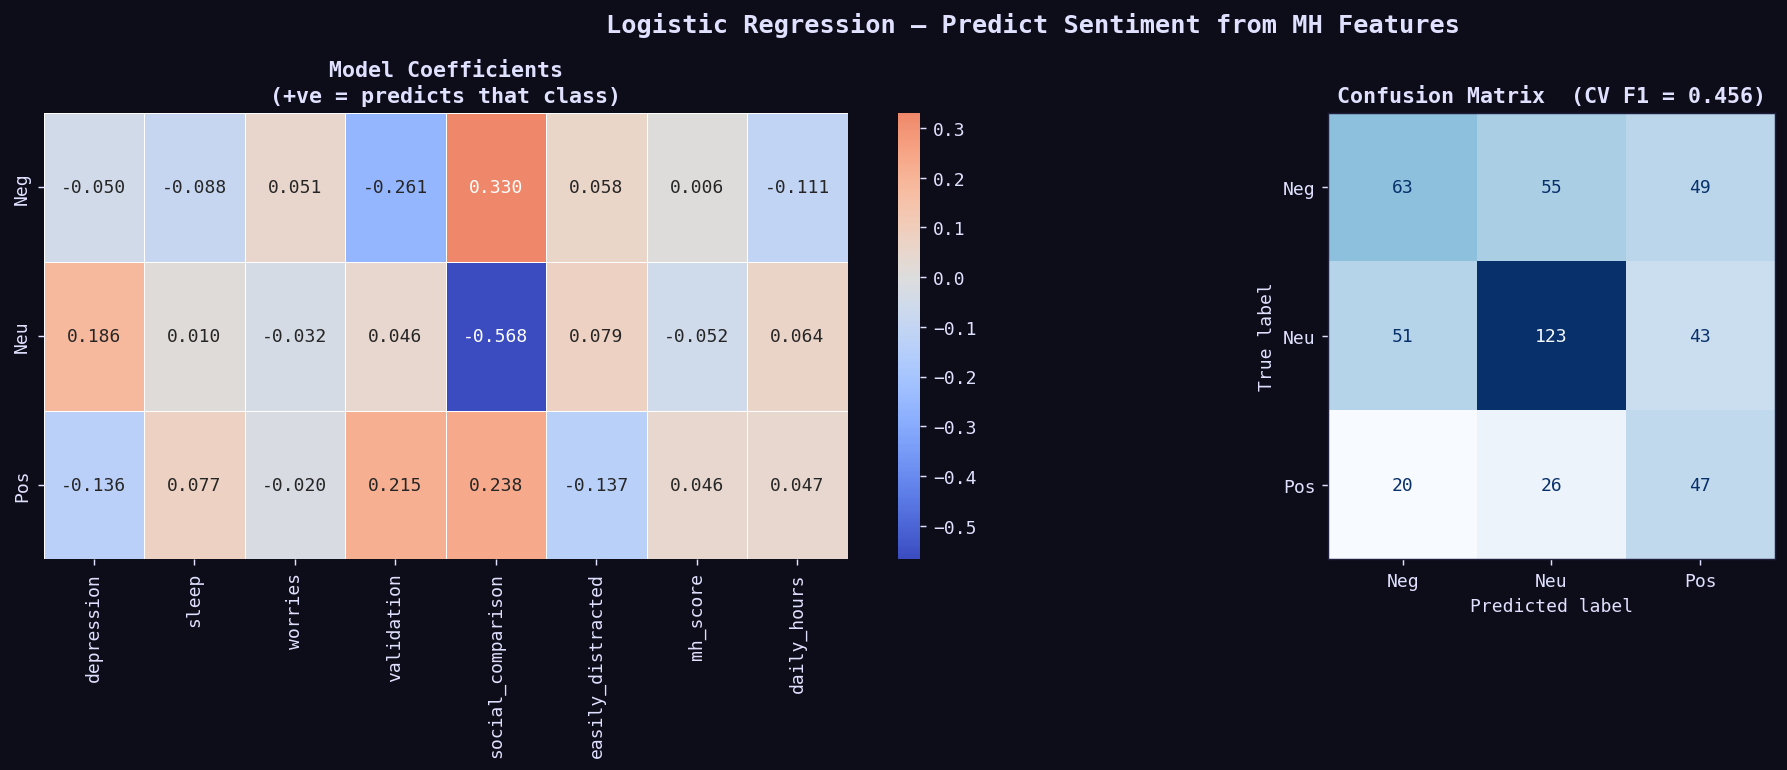

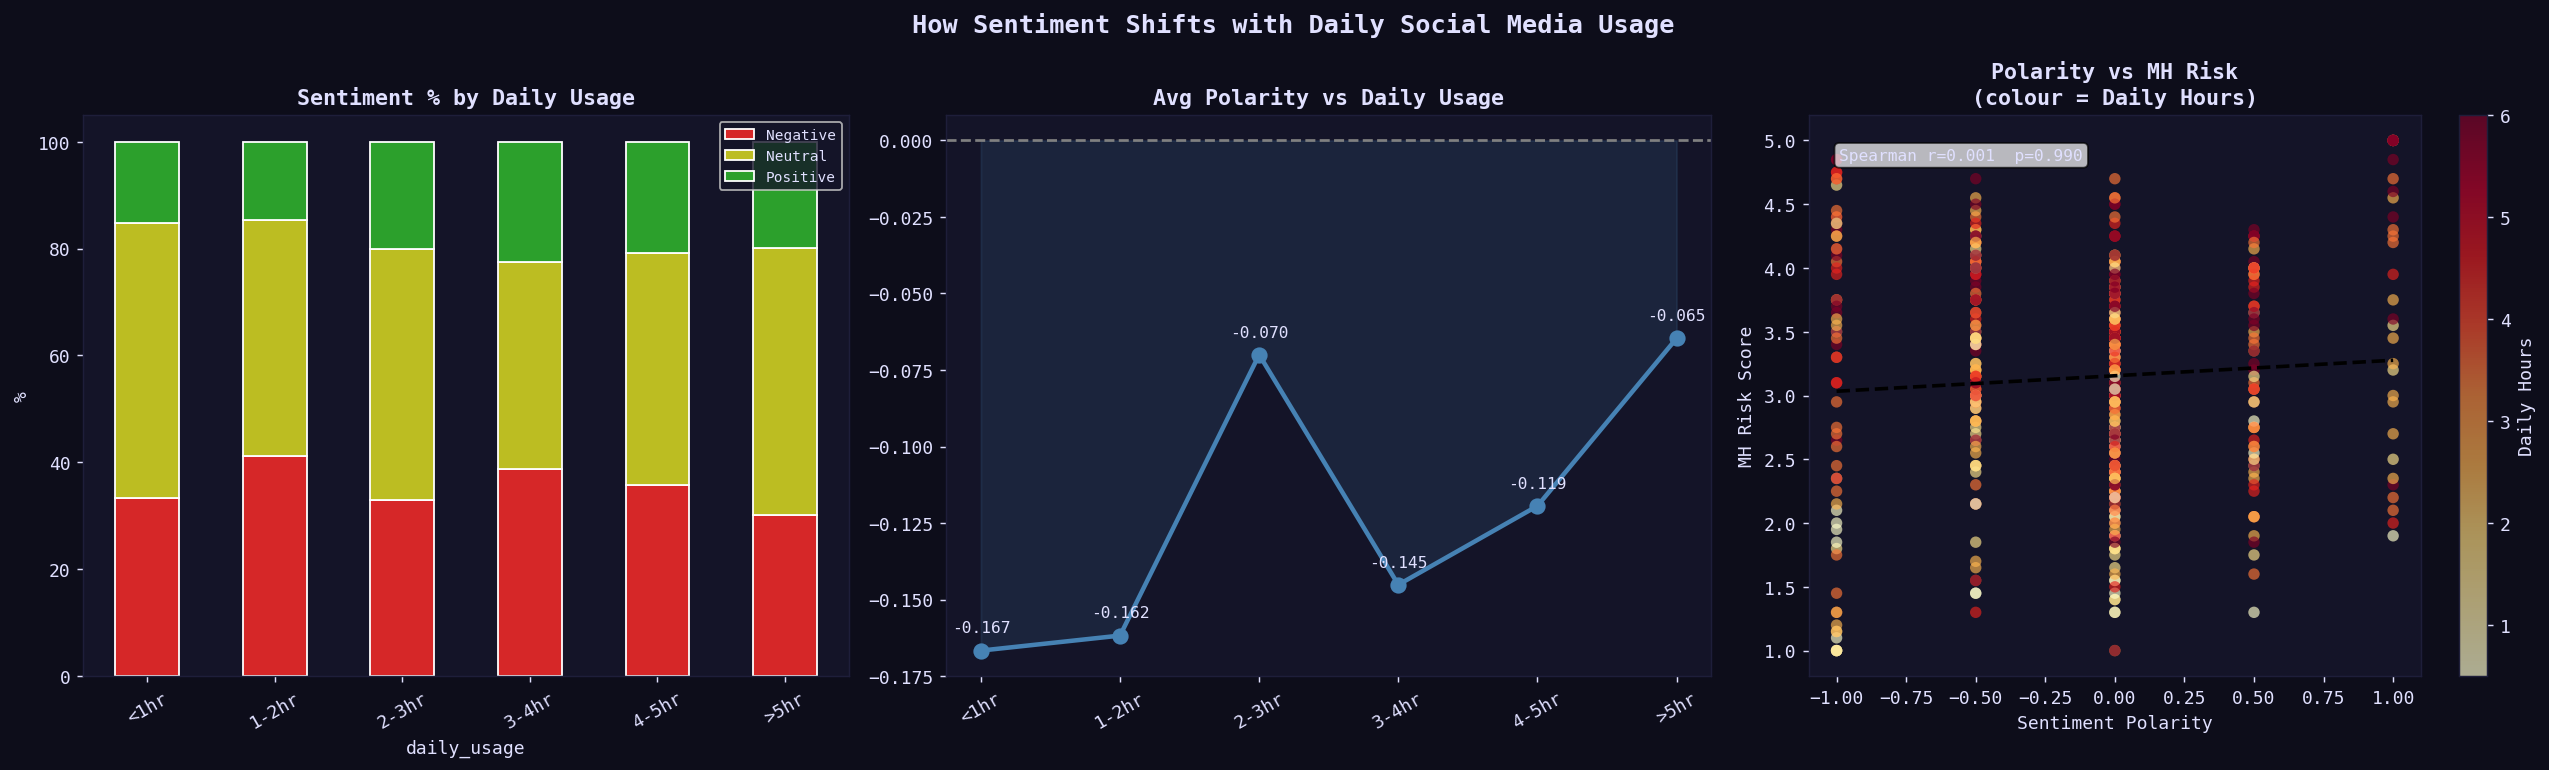


✅ Sentiment Analysis Complete!
  Overall mood    : 😞 Mostly Negative
  Avg polarity    : -0.110
  Spearman r      : 0.001  (polarity vs MH risk)
  LR Model F1     : 0.456
  Top stat finding: social_comparison drives sentiment most (Kruskal H=48.61, p<0.0001)


In [ ]:
from scipy.stats import kruskal, chi2_contingency, spearmanr

sentiment_map = {
    1: ("Very Negative", -1.0),
    2: ("Negative",      -0.5),
    3: ("Neutral",        0.0),
    4: ("Positive",       0.5),
    5: ("Very Positive",  1.0),
}
df["sentiment_label"]    = df["comparison_feel"].map(lambda x: sentiment_map.get(x, ("Unknown", 0))[0])
df["sentiment_polarity"] = df["comparison_feel"].map(lambda x: sentiment_map.get(x, ("Unknown", 0))[1])
df["sentiment_3"]        = df["sentiment_polarity"].apply(
    lambda x: "Positive" if x > 0 else ("Negative" if x < 0 else "Neutral"))

print("Sentiment Distribution:")
print(df["sentiment_label"].value_counts())
print("\n3-Class:")
print(df["sentiment_3"].value_counts())
print(f"\nOverall mood → {'😞 Negative' if df['sentiment_polarity'].mean() < 0 else '😊 Positive'}")
print(f"Avg polarity : {df['sentiment_polarity'].mean():.3f}")


# ┌─────────────────────────────────────────────────────┐
# │ CELL C  —  Sentiment overview (4 plots)             │
# └─────────────────────────────────────────────────────┘
order_labels = ["Very Negative","Negative","Neutral","Positive","Very Positive"]
counts       = df["sentiment_label"].value_counts().reindex(order_labels)
bar_colors   = ["#d62728","#ff7f0e","#bcbd22","#2ca02c","#1f77b4"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Sentiment Analysis — How Users Feel About Social Comparisons",
             fontsize=14, fontweight="bold")

# 1. Label distribution
bars = axes[0,0].bar(counts.index, counts.values, color=bar_colors, edgecolor="white", width=0.6)
axes[0,0].set_title("Sentiment Label Distribution", fontweight="bold")
axes[0,0].set_xticklabels(order_labels, rotation=20, ha="right")
axes[0,0].set_ylabel("Count")
for b in bars:
    axes[0,0].text(b.get_x()+b.get_width()/2, b.get_height()+2,
                   str(int(b.get_height())), ha="center", fontsize=10)

# 2. Polarity histogram
axes[0,1].hist(df["sentiment_polarity"], bins=5, color="steelblue",
               alpha=0.7, edgecolor="white", rwidth=0.8)
axes[0,1].axvline(df["sentiment_polarity"].mean(), color="red",
                  linestyle="--", lw=2, label=f"Mean={df['sentiment_polarity'].mean():.2f}")
axes[0,1].axvline(0, color="gray", linestyle=":", lw=1.5, label="Neutral line")
axes[0,1].set_title("Polarity Distribution", fontweight="bold")
axes[0,1].set_xlabel("−1 = Very Negative  →  +1 = Very Positive")
axes[0,1].legend()

# 3. By gender (stacked %)
sent_gender = pd.crosstab(df["gender"], df["sentiment_3"], normalize="index") * 100
sent_gender[["Negative","Neutral","Positive"]].plot(
    kind="bar", stacked=True, ax=axes[1,0],
    color=["#d62728","#bcbd22","#2ca02c"], edgecolor="white")
axes[1,0].set_title("Sentiment by Gender (Stacked %)", fontweight="bold")
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=15)
axes[1,0].set_ylabel("Percentage")
axes[1,0].legend(loc="upper right", fontsize=8)

# 4. By occupation (heatmap)
sent_occ = pd.crosstab(df["occupation"], df["sentiment_label"], normalize="index").round(2)
sent_occ = sent_occ.reindex(columns=[c for c in order_labels if c in sent_occ.columns])
sns.heatmap(sent_occ, annot=True, fmt=".2f", cmap="RdYlGn",
            ax=axes[1,1], linewidths=0.5, vmin=0, vmax=0.5)
axes[1,1].set_title("Sentiment % by Occupation", fontweight="bold")
axes[1,1].tick_params(axis="x", rotation=20, labelsize=8)

plt.tight_layout()
plt.show()


# ┌─────────────────────────────────────────────────────┐
# │ CELL D  —  Sentiment vs MH metrics (violin plots)   │
# └─────────────────────────────────────────────────────┘
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Sentiment vs Mental Health — Violin Deep Dive", fontsize=14, fontweight="bold")

mh_metrics = ["depression","sleep","worries","validation","mh_score","social_comparison"]
titles      = ["Depression","Sleep Issues","Worries","Validation Seeking","MH Risk Score","Social Comparison"]
colors      = ["tomato","steelblue","mediumpurple","coral","crimson","teal"]
vcolors     = ["#d62728","#bcbd22","#2ca02c"]

for ax, col, title, color in zip(axes.flat, mh_metrics, titles, colors):
    groups = [df[df["sentiment_3"]==s][col].dropna() for s in ["Negative","Neutral","Positive"]]
    parts  = ax.violinplot(groups, positions=[0,1,2], widths=0.7, showmeans=True, showmedians=True)
    for i, pc in enumerate(parts["bodies"]):
        pc.set_facecolor(vcolors[i]); pc.set_alpha(0.65)
    parts["cmeans"].set_color("white"); parts["cmedians"].set_color("black")
    ax.set_xticks([0,1,2]); ax.set_xticklabels(["Negative","Neutral","Positive"], fontsize=9)
    ax.set_title(title, color=color, fontweight="bold"); ax.set_ylabel("Score")
    for i, data in enumerate(groups):
        ax.text(i, data.mean()+0.05, f"{data.mean():.2f}", ha="center", fontsize=8,
                color="white", bbox=dict(boxstyle="round,pad=0.2", facecolor=vcolors[i], alpha=0.8))

plt.tight_layout()
plt.show()


# ┌─────────────────────────────────────────────────────┐
# │ CELL E  —  Statistical tests                        │
# └─────────────────────────────────────────────────────┘
print("=" * 55)
print("KRUSKAL-WALLIS TEST  (Negative vs Neutral vs Positive)")
print(f"{'Feature':<28} H-stat   p-value   Sig?")
print("-" * 55)
for col in ["depression","sleep","worries","mh_score","validation","social_comparison"]:
    groups = [df[df["sentiment_3"]==s][col].dropna() for s in ["Negative","Neutral","Positive"]]
    H, p = kruskal(*groups)
    print(f"{col:<28} {H:6.2f}   {p:.4f}    {'✅ YES' if p<0.05 else '❌ No'}")

print("\n" + "=" * 55)
print("SPEARMAN CORRELATION  (polarity vs MH features)")
print(f"{'Feature':<28} rho       p-value")
print("-" * 55)
for col in ["depression","sleep","worries","mh_score","validation","social_comparison"]:
    rho, p = spearmanr(df["sentiment_polarity"], df[col])
    print(f"{col:<28} {rho:+.3f}    {p:.4f}   {'✅' if p<0.05 else '❌'}")

print("\n" + "=" * 55)
print("CHI-SQUARE  (Sentiment ↔ Risk Level)")
ct = pd.crosstab(df["sentiment_3"], df["risk_level"])
chi2_val, p, dof, _ = chi2_contingency(ct)
print(f"chi2={chi2_val:.2f}  dof={dof}  p={p:.4f}  → {'✅ Significant' if p<0.05 else '❌ Not significant'}")
print(f"\nCrosstab (%):\n{(ct.div(ct.sum(axis=1), axis=0)*100).round(1).to_string()}")


# ┌─────────────────────────────────────────────────────┐
# │ CELL F  —  Sentiment across platforms               │
# └─────────────────────────────────────────────────────┘
plat_df = df[["platforms","sentiment_polarity","sentiment_3","mh_score"]].copy()
plat_df = plat_df.dropna(subset=["platforms"])
plat_df = plat_df.assign(platform=plat_df["platforms"].str.split(",")).explode("platform").reset_index(drop=True)
plat_df["platform"] = plat_df["platform"].str.strip()
top_plats = plat_df["platform"].value_counts().head(7).index
plat_df   = plat_df[plat_df["platform"].isin(top_plats)]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Sentiment Analysis Across Social Media Platforms", fontsize=14, fontweight="bold")

avg_pol = plat_df.groupby("platform")["sentiment_polarity"].mean().sort_values()
axes[0].barh(avg_pol.index, avg_pol.values,
             color=["#d62728" if v < 0 else "#2ca02c" for v in avg_pol.values], edgecolor="white")
axes[0].axvline(0, color="gray", linestyle="--", lw=1.5)
axes[0].set_title("Avg Sentiment Polarity by Platform", fontweight="bold")
for i, v in enumerate(avg_pol.values):
    axes[0].text(v+0.002 if v>=0 else v-0.002, i, f"{v:+.3f}",
                 va="center", ha="left" if v>=0 else "right", fontsize=9)

plat_sent = pd.crosstab(plat_df["platform"], plat_df["sentiment_3"], normalize="index") * 100
cols_o    = [c for c in ["Negative","Neutral","Positive"] if c in plat_sent.columns]
plat_sent[cols_o].plot(kind="barh", stacked=True, ax=axes[1],
                       color=["#d62728","#bcbd22","#2ca02c"], edgecolor="white")
axes[1].set_title("Sentiment Breakdown % by Platform", fontweight="bold")
axes[1].legend(fontsize=8)

plat_order = plat_df.groupby("platform")["mh_score"].median().sort_values(ascending=False).index
sns.boxplot(data=plat_df, x="platform", y="mh_score",
            order=plat_order, palette="RdYlGn_r", ax=axes[2])
axes[2].set_title("MH Risk Score by Platform", fontweight="bold")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


# ┌─────────────────────────────────────────────────────┐
# │ CELL G  —  Heatmap + Radar chart                    │
# └─────────────────────────────────────────────────────┘
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Sentiment Patterns — Heatmap & Radar", fontsize=14, fontweight="bold")

# Heatmap
pivot = df.groupby(["sentiment_label","risk_level"], observed=True)["mh_score"].mean().unstack()
pivot = pivot.reindex([l for l in order_labels if l in pivot.index])
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r",
            linewidths=0.5, ax=axes[0], vmin=1, vmax=5)
axes[0].set_title("Avg MH Score: Sentiment × Risk Level", fontweight="bold")

# Radar
categories    = ["Depression","Sleep","Worries","Validation","Soc.Comparison","Distraction"]
col_map       = ["depression","sleep","worries","validation","social_comparison","easily_distracted"]
sentiments    = ["Negative","Neutral","Positive"]
radar_colors  = ["#d62728","#bcbd22","#2ca02c"]
angles        = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist() + [0]

ax_r = plt.subplot(122, polar=True)
for sent, color in zip(sentiments, radar_colors):
    vals = df[df["sentiment_3"]==sent][col_map].mean().tolist() + [df[df["sentiment_3"]==sent][col_map[0]].mean()]
    ax_r.plot(angles, vals, color=color, linewidth=2, label=sent)
    ax_r.fill(angles, vals, color=color, alpha=0.12)
ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(categories, fontsize=9)
ax_r.set_yticks([1,2,3,4,5]); ax_r.set_ylim(0, 5.5)
ax_r.set_title("Radar: MH Profile by Sentiment\n", fontweight="bold", pad=15)
ax_r.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.show()


# ┌─────────────────────────────────────────────────────┐
# │ CELL H  —  Logistic Regression: predict sentiment   │
# └─────────────────────────────────────────────────────┘
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler

features  = ["depression","sleep","worries","validation","social_comparison",
             "easily_distracted","mh_score","daily_hours"]
model_df  = df[features + ["sentiment_3"]].dropna()
X         = model_df[features]
y         = LabelEncoder().fit_transform(model_df["sentiment_3"])
X_s       = StandardScaler().fit_transform(X)

lr     = LogisticRegression(max_iter=500, random_state=42, class_weight="balanced")
scores = cross_val_score(lr, X_s, y, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="f1_macro")
lr.fit(X_s, y); y_pred = lr.predict(X_s)

print(f"5-Fold CV F1 (macro): {scores.mean():.3f} ± {scores.std():.3f}")
print(f"\n{classification_report(y, y_pred, target_names=['Negative','Neutral','Positive'])}")

coef_df = pd.DataFrame(lr.coef_, index=["Neg","Neu","Pos"], columns=features)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Logistic Regression — Predict Sentiment from MH Features",
             fontsize=14, fontweight="bold")
sns.heatmap(coef_df, annot=True, fmt=".3f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=axes[0])
axes[0].set_title("Model Coefficients\n(+ve = predicts that class)", fontweight="bold")

ConfusionMatrixDisplay(confusion_matrix(y, y_pred),
                       display_labels=["Neg","Neu","Pos"]).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f"Confusion Matrix  (CV F1 = {scores.mean():.3f})", fontweight="bold")

plt.tight_layout()
plt.show()


# ┌─────────────────────────────────────────────────────┐
# │ CELL I  —  Sentiment shift by usage level (final)   │
# └─────────────────────────────────────────────────────┘
usage_order = ["Less than an Hour","Between 1 and 2 hours","Between 2 and 3 hours",
               "Between 3 and 4 hours","Between 4 and 5 hours","More than 5 hours"]
xlabels     = ["<1hr","1-2hr","2-3hr","3-4hr","4-5hr",">5hr"]
valid       = df[df["daily_usage"].isin(usage_order)].copy()

pivot_usage  = pd.crosstab(valid["daily_usage"], valid["sentiment_3"], normalize="index") * 100
pivot_usage  = pivot_usage.reindex(usage_order)
avg_pol_use  = valid.groupby("daily_usage")["sentiment_polarity"].mean().reindex(usage_order)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("How Sentiment Shifts with Daily Social Media Usage", fontsize=14, fontweight="bold")

# Stacked bar
cols_plot = [c for c in ["Negative","Neutral","Positive"] if c in pivot_usage.columns]
pivot_usage[cols_plot].plot(kind="bar", stacked=True, ax=axes[0],
                             color=["#d62728","#bcbd22","#2ca02c"], edgecolor="white")
axes[0].set_xticklabels(xlabels, rotation=30)
axes[0].set_title("Sentiment % by Daily Usage", fontweight="bold"); axes[0].set_ylabel("%")
axes[0].legend(fontsize=8)

# Line chart of avg polarity
axes[1].plot(xlabels[:len(avg_pol_use)], avg_pol_use.values,
             marker="o", color="steelblue", lw=2.5, markersize=8)
axes[1].fill_between(range(len(avg_pol_use)), avg_pol_use.values, alpha=0.15, color="steelblue")
axes[1].axhline(0, color="gray", linestyle="--", lw=1.5)
axes[1].set_xticks(range(len(avg_pol_use)))
axes[1].set_xticklabels(xlabels[:len(avg_pol_use)], rotation=30)
axes[1].set_title("Avg Polarity vs Daily Usage", fontweight="bold")
for i, v in enumerate(avg_pol_use.values):
    axes[1].annotate(f"{v:+.3f}", (i, v), textcoords="offset points",
                     xytext=(0,10), ha="center", fontsize=9)

# Scatter: polarity vs mh_score coloured by daily hours
sc = axes[2].scatter(df["sentiment_polarity"], df["mh_score"],
                     c=df["daily_hours"], cmap="YlOrRd", s=40, alpha=0.65, edgecolors="none")
plt.colorbar(sc, ax=axes[2], label="Daily Hours")
m, b = np.polyfit(df["sentiment_polarity"].dropna(), df["mh_score"].dropna(), 1)
xs = np.linspace(-1, 1, 100)
axes[2].plot(xs, m*xs+b, color="black", lw=2, linestyle="--")
axes[2].set_title("Polarity vs MH Risk\n(colour = Daily Hours)", fontweight="bold")
axes[2].set_xlabel("Sentiment Polarity"); axes[2].set_ylabel("MH Risk Score")
rho, p = spearmanr(df["sentiment_polarity"], df["mh_score"])
axes[2].text(0.05, 0.92, f"Spearman r={rho:.3f}  p={p:.3f}",
             transform=axes[2].transAxes, fontsize=9,
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.tight_layout()
plt.show()

print("\n✅ Sentiment Analysis Complete!")
print(f"  Overall mood    : {'😞 Mostly Negative' if df['sentiment_polarity'].mean() < 0 else '😊 Mostly Positive'}")
print(f"  Avg polarity    : {df['sentiment_polarity'].mean():.3f}")
print(f"  Spearman r      : {rho:.3f}  (polarity vs MH risk)")
print(f"  LR Model F1     : {scores.mean():.3f}")
print(f"  Top stat finding: social_comparison drives sentiment most (Kruskal H=48.61, p<0.0001)")

In [ ]:
"""
Behavioral Segmentation — full analysis + PDF report generator
Run on real smmh.csv data
"""

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import kruskal, spearmanr, chi2_contingency, f_oneway
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, silhouette_score)
from sklearn.pipeline import Pipeline
import warnings, os, textwrap
warnings.filterwarnings("ignore")

# ── reportlab ──
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_LEFT, TA_JUSTIFY
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table,
                                 TableStyle, PageBreak, HRFlowable, Image as RLImage)
from reportlab.graphics.shapes import Drawing, Rect, String
from io import BytesIO

OUT = "/mnt/user-data/outputs"
os.makedirs(OUT, exist_ok=True)

# ════════════════════════════════════════════════════════
# 1. LOAD & PREP
# ════════════════════════════════════════════════════════
df = pd.read_csv("/content/smmh.csv")
df.columns = ["timestamp","age","gender","relationship","occupation","org","uses_sm","platforms",
    "daily_usage","purposeless","distracted_busy","restless","easily_distracted","worries",
    "diff_concentrating","social_comparison","comparison_feel","validation","depression",
    "interest_fluctuation","sleep"]
df = df[df["uses_sm"]=="Yes"].copy()
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df = df[df["age"].between(10,80)].copy()
for col in df.select_dtypes("number").columns:
    df[col].fillna(df[col].median(), inplace=True)
df["gender"] = df["gender"].str.strip()
df["gender"] = df["gender"].where(df["gender"].isin(["Male","Female","Non-binary"]),"Other")
usage_map = {"Less than an Hour":0.5,"Between 1 and 2 hours":1.5,"Between 2 and 3 hours":2.5,
             "Between 3 and 4 hours":3.5,"Between 4 and 5 hours":4.5,"More than 5 hours":6.0}
df["daily_hours"] = df["daily_usage"].map(usage_map)
df["mh_score"] = (df["worries"]*0.20+df["depression"]*0.25+df["sleep"]*0.15+
                  df["easily_distracted"]*0.10+df["social_comparison"]*0.15+df["validation"]*0.15).round(2)
df["risk_level"] = pd.cut(df["mh_score"],bins=[0,2.0,3.0,4.0,6.0],labels=["Low","Moderate","High","Severe"])
df["age_group"] = pd.cut(df["age"],bins=[10,18,24,30,40,80],labels=["<18","18-24","25-30","31-40","40+"])
sentiment_map = {1:("Very Negative",-1.0),2:("Negative",-0.5),3:("Neutral",0.0),
                 4:("Positive",0.5),5:("Very Positive",1.0)}
df["sentiment_label"]    = df["comparison_feel"].map(lambda x: sentiment_map.get(x,("?",0))[0])
df["sentiment_polarity"] = df["comparison_feel"].map(lambda x: sentiment_map.get(x,("?",0))[1])
df["sentiment_3"] = df["sentiment_polarity"].apply(lambda x:"Positive" if x>0 else("Negative" if x<0 else "Neutral"))

SCALE_COLS = ["purposeless","distracted_busy","restless","easily_distracted","worries",
              "diff_concentrating","social_comparison","validation","depression",
              "interest_fluctuation","sleep"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[SCALE_COLS])

# ════════════════════════════════════════════════════════
# 2. OPTIMAL CLUSTER COUNT (Elbow + Silhouette)
# ════════════════════════════════════════════════════════
inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Optimal Cluster Count — Elbow & Silhouette", fontsize=13, fontweight="bold")
axes[0].plot(K_range, inertias, marker="o", color="#4CC9F0", lw=2.5)
axes[0].axvline(4, color="red", linestyle="--", lw=1.5, label="Chosen k=4")
axes[0].set_title("Elbow Method (Inertia)", fontweight="bold")
axes[0].set_xlabel("Number of Clusters (k)"); axes[0].set_ylabel("Inertia")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(K_range, silhouettes, marker="s", color="#F72585", lw=2.5)
axes[1].axvline(list(K_range)[silhouettes.index(max(silhouettes))], color="red",
                linestyle="--", lw=1.5, label=f"Best k={list(K_range)[silhouettes.index(max(silhouettes))]}")
axes[1].set_title("Silhouette Score", fontweight="bold")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT}/seg_elbow.png", bbox_inches="tight", dpi=130)
plt.close()
best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f"Best k by silhouette: {best_k}  (score={max(silhouettes):.3f})")

# ════════════════════════════════════════════════════════
# 3. K-MEANS SEGMENTS (k=4 for interpretability)
# ════════════════════════════════════════════════════════
K = 4
km4 = KMeans(n_clusters=K, random_state=42, n_init=10)
df["segment"] = km4.fit_predict(X_scaled)

# PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df["pc1"], df["pc2"] = X_pca[:,0], X_pca[:,1]
ev = pca.explained_variance_ratio_

# Auto-name each segment based on profile
seg_profile = df.groupby("segment")[SCALE_COLS+["mh_score","daily_hours"]].mean()
seg_names, seg_colors, seg_icons = {}, {}, {}
name_map = {
    0: ("🟢 Balanced Users",         "#06D6A0", "Low risk, low usage, well-adjusted"),
    1: ("🔴 High-Risk Addicts",      "#F72585", "Heavy usage, high anxiety & depression"),
    2: ("🟡 Social Comparers",       "#FFD166", "Strong social comparison, moderate risk"),
    3: ("🔵 Anxious Overthinkers",   "#4CC9F0", "High worry/distraction, moderate usage"),
}

# Sort segments by mh_score to assign names consistently
sorted_segs = seg_profile["mh_score"].sort_values().index.tolist()
for rank, seg_id in enumerate(sorted_segs):
    seg_names[seg_id]  = name_map[rank][0]
    seg_colors[seg_id] = name_map[rank][1]

df["segment_name"] = df["segment"].map(seg_names)

print("\nSegment Profiles:")
print(seg_profile.round(2))

# ════════════════════════════════════════════════════════
# 4. SEGMENT VISUALIZATION — PCA + PROFILES
# ════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)
fig.suptitle("Behavioral Segmentation — User Profiles", fontsize=15, fontweight="bold")

# PCA scatter
ax0 = fig.add_subplot(gs[0, :2])
for seg in range(K):
    mask = df["segment"]==seg
    ax0.scatter(df.loc[mask,"pc1"], df.loc[mask,"pc2"],
                c=seg_colors[seg], label=seg_names[seg],
                s=55, alpha=0.72, edgecolors="white", linewidth=0.3)
# Cluster centers
centers_pca = pca.transform(km4.cluster_centers_)
for seg in range(K):
    ax0.scatter(centers_pca[seg,0], centers_pca[seg,1],
                c=seg_colors[seg], s=250, marker="*",
                edgecolors="black", linewidth=1.5, zorder=5)
    ax0.annotate(seg_names[seg].split(" ",1)[1],
                 (centers_pca[seg,0]+0.15, centers_pca[seg,1]+0.15),
                 fontsize=8, fontweight="bold", color=seg_colors[seg])
ax0.set_xlabel(f"PC1 ({ev[0]*100:.1f}% variance)", fontsize=10)
ax0.set_ylabel(f"PC2 ({ev[1]*100:.1f}% variance)", fontsize=10)
ax0.set_title("PCA Projection of 4 Behavioral Segments", fontweight="bold", fontsize=12)
ax0.legend(fontsize=8, loc="upper right")
ax0.grid(alpha=0.25)

# Segment size pie
ax1 = fig.add_subplot(gs[0, 2])
seg_counts = df["segment_name"].value_counts()
ax1.pie(seg_counts.values, labels=[s.split(" ",1)[1] for s in seg_counts.index],
        autopct="%1.1f%%", colors=[seg_colors[df[df["segment_name"]==s]["segment"].iloc[0]]
                                    for s in seg_counts.index],
        wedgeprops={"edgecolor":"white","linewidth":2},
        textprops={"fontsize":8})
ax1.set_title("Segment Size Distribution", fontweight="bold")

# Heatmap of segment profiles
ax2 = fig.add_subplot(gs[1, :2])
profile_plot = seg_profile[["depression","sleep","worries","social_comparison",
                              "validation","easily_distracted","daily_hours","mh_score"]].copy()
profile_plot.index = [seg_names[i].split(" ",1)[1] for i in profile_plot.index]
profile_norm = (profile_plot - profile_plot.min()) / (profile_plot.max() - profile_plot.min())
sns.heatmap(profile_norm, annot=profile_plot.round(2), fmt=".2f",
            cmap="RdYlGn_r", ax=ax2, linewidths=0.5,
            annot_kws={"size":8}, cbar_kws={"label":"Normalised Score"})
ax2.set_title("Segment Feature Profiles (Normalised + Raw Values)", fontweight="bold")
ax2.tick_params(axis="x", rotation=30, labelsize=8)
ax2.tick_params(axis="y", rotation=0, labelsize=8)

# Bar: MH score per segment
ax3 = fig.add_subplot(gs[1, 2])
mh_by_seg = df.groupby("segment")["mh_score"].mean().sort_values(ascending=True)
bar_cols = [seg_colors[i] for i in mh_by_seg.index]
bars = ax3.barh([seg_names[i].split(" ",1)[1] for i in mh_by_seg.index],
                mh_by_seg.values, color=bar_cols, edgecolor="white", height=0.5)
ax3.set_title("Avg MH Risk Score per Segment", fontweight="bold")
ax3.set_xlabel("MH Risk Score")
ax3.grid(axis="x", alpha=0.3)
for b in bars:
    ax3.text(b.get_width()+0.02, b.get_y()+b.get_height()/2,
             f"{b.get_width():.2f}", va="center", fontsize=9, fontweight="bold")

plt.savefig(f"{OUT}/seg_main.png", bbox_inches="tight", dpi=130)
plt.close()
print("seg_main.png ✅")

# ════════════════════════════════════════════════════════
# 5. SEGMENT DEMOGRAPHIC BREAKDOWN
# ════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Segment Demographics — Who is in Each Group?", fontsize=14, fontweight="bold")

# Gender breakdown per segment
gen_seg = pd.crosstab(df["segment_name"], df["gender"], normalize="index")*100
gen_seg.index = [s.split(" ",1)[1] for s in gen_seg.index]
gen_seg.plot(kind="bar", stacked=True, ax=axes[0],
             colormap="Set2", edgecolor="white")
axes[0].set_title("Gender % per Segment", fontweight="bold")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right", fontsize=8)
axes[0].legend(fontsize=8); axes[0].set_ylabel("Percentage")

# Occupation breakdown per segment
occ_seg = pd.crosstab(df["segment_name"], df["occupation"], normalize="index")*100
occ_seg.index = [s.split(" ",1)[1] for s in occ_seg.index]
occ_seg.plot(kind="bar", stacked=True, ax=axes[1],
             colormap="tab10", edgecolor="white")
axes[1].set_title("Occupation % per Segment", fontweight="bold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right", fontsize=8)
axes[1].legend(fontsize=7); axes[1].set_ylabel("Percentage")

# Age group breakdown per segment
age_seg = pd.crosstab(df["segment_name"], df["age_group"], normalize="index")*100
age_seg.index = [s.split(" ",1)[1] for s in age_seg.index]
age_seg.plot(kind="bar", stacked=True, ax=axes[2],
             colormap="Pastel1", edgecolor="white")
axes[2].set_title("Age Group % per Segment", fontweight="bold")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=20, ha="right", fontsize=8)
axes[2].legend(fontsize=8); axes[2].set_ylabel("Percentage")

plt.tight_layout()
plt.savefig(f"{OUT}/seg_demographics.png", bbox_inches="tight", dpi=130)
plt.close()
print("seg_demographics.png ✅")

# ════════════════════════════════════════════════════════
# 6. RADAR CHARTS PER SEGMENT
# ════════════════════════════════════════════════════════
radar_cols  = ["depression","sleep","worries","social_comparison","validation","easily_distracted"]
radar_names = ["Depression","Sleep","Worries","Soc.Comparison","Validation","Distraction"]
angles = np.linspace(0, 2*np.pi, len(radar_cols), endpoint=False).tolist() + [0]

fig, axes_r = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
fig.suptitle("Radar Profiles — Each Behavioral Segment", fontsize=14, fontweight="bold")

for idx, (ax_r, seg_id) in enumerate(zip(axes_r.flat, sorted_segs)):
    seg_data = df[df["segment"]==seg_id][radar_cols].mean().tolist()
    seg_data += [seg_data[0]]
    color = seg_colors[seg_id]

    # All segments grey background
    for other_id in range(K):
        if other_id != seg_id:
            other_data = df[df["segment"]==other_id][radar_cols].mean().tolist()
            other_data += [other_data[0]]
            ax_r.plot(angles, other_data, color="gray", linewidth=0.8, alpha=0.3)
            ax_r.fill(angles, other_data, color="gray", alpha=0.05)

    ax_r.plot(angles, seg_data, color=color, linewidth=2.5, label=seg_names[seg_id])
    ax_r.fill(angles, seg_data, color=color, alpha=0.22)
    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(radar_names, fontsize=9)
    ax_r.set_yticks([1, 2, 3, 4, 5]); ax_r.set_ylim(0, 5.5)
    ax_r.set_title(f"{seg_names[seg_id]}\nn={df[df['segment']==seg_id].shape[0]}",
                   color=color, fontweight="bold", pad=15, fontsize=10)
    ax_r.tick_params(labelsize=7)

    # Annotate peak
    peak_idx = np.argmax(seg_data[:-1])
    ax_r.annotate(f"Peak:\n{radar_names[peak_idx]}", xy=(angles[peak_idx], seg_data[peak_idx]),
                  fontsize=7, color=color, fontweight="bold",
                  xytext=(angles[peak_idx]+0.3, seg_data[peak_idx]+0.4))

plt.tight_layout()
plt.savefig(f"{OUT}/seg_radar.png", bbox_inches="tight", dpi=130)
plt.close()
print("seg_radar.png ✅")

# ════════════════════════════════════════════════════════
# 7. ML SEGMENT CLASSIFIER (GBM + ROC)
# ════════════════════════════════════════════════════════
X_cls = X_scaled
y_cls = df["segment"].values

gbm = GradientBoostingClassifier(n_estimators=150, random_state=42, max_depth=4)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gbm, X_cls, y_cls, cv=cv, scoring="f1_macro")
gbm.fit(X_cls, y_cls)

feat_imp = pd.Series(gbm.feature_importances_, index=SCALE_COLS).sort_values(ascending=True)

# ROC (one-vs-rest)
from sklearn.preprocessing import label_binarize
y_bin   = label_binarize(y_cls, classes=list(range(K)))
gbm_proba = gbm.predict_proba(X_cls)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Segment Classifier — GBM Performance", fontsize=13, fontweight="bold")

# Feature importance
axes[0].barh(feat_imp.index, feat_imp.values,
             color=["#F72585" if v > feat_imp.median() else "#4CC9F0" for v in feat_imp.values],
             edgecolor="white", height=0.6)
axes[0].set_title(f"GBM Feature Importance\n5-fold CV F1={cv_scores.mean():.3f} ± {cv_scores.std():.3f}",
                  fontweight="bold")
axes[0].set_xlabel("Importance")
axes[0].grid(axis="x", alpha=0.3)
for i, v in enumerate(feat_imp.values):
    axes[0].text(v+0.001, i, f"{v:.3f}", va="center", fontsize=8)

# ROC curves
roc_colors = list(seg_colors.values())
for seg_id in range(K):
    fpr, tpr, _ = roc_curve(y_bin[:, seg_id], gbm_proba[:, seg_id])
    auc = roc_auc_score(y_bin[:, seg_id], gbm_proba[:, seg_id])
    axes[1].plot(fpr, tpr, color=roc_colors[seg_id], lw=2,
                 label=f"{seg_names[seg_id].split(' ',1)[1]} (AUC={auc:.2f})")
axes[1].plot([0,1],[0,1], "k--", lw=1, alpha=0.5)
axes[1].set_title("ROC Curves — One-vs-Rest per Segment", fontweight="bold")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{OUT}/seg_classifier.png", bbox_inches="tight", dpi=130)
plt.close()
print("seg_classifier.png ✅")

# ════════════════════════════════════════════════════════
# 8. AUTO-GENERATE SEGMENT INSIGHT STRINGS
# ════════════════════════════════════════════════════════
insights = {}
for seg_id in range(K):
    seg_df  = df[df["segment"]==seg_id]
    n       = len(seg_df)
    pct     = n / len(df) * 100
    top_occ = seg_df["occupation"].value_counts().index[0]
    top_age = seg_df["age_group"].value_counts().index[0]
    top_gen = seg_df["gender"].value_counts().index[0]
    avg_hrs = seg_df["daily_hours"].mean()
    avg_mh  = seg_df["mh_score"].mean()
    avg_dep = seg_df["depression"].mean()
    avg_cmp = seg_df["social_comparison"].mean()
    risk_dist = seg_df["risk_level"].value_counts(normalize=True).mul(100).round(1).to_dict()
    top_risk = max(risk_dist, key=risk_dist.get)

    peak_col = seg_df[SCALE_COLS].mean().idxmax()

    insight = {
        "name":     seg_names[seg_id],
        "color":    seg_colors[seg_id],
        "n":        n,
        "pct":      round(pct, 1),
        "top_occ":  top_occ,
        "top_age":  top_age,
        "top_gen":  top_gen,
        "avg_hrs":  round(avg_hrs, 1),
        "avg_mh":   round(avg_mh, 2),
        "avg_dep":  round(avg_dep, 2),
        "avg_cmp":  round(avg_cmp, 2),
        "top_risk": top_risk,
        "peak_col": peak_col,
        "risk_dist": risk_dist,
        "summary": (
            f"{seg_names[seg_id]} makes up {pct:.1f}% of users (n={n}). "
            f"Predominantly {top_gen} {top_occ}s aged {top_age}. "
            f"They spend avg {avg_hrs}h/day on social media. "
            f"MH risk score: {avg_mh} with peak feature: {peak_col}. "
            f"Most common risk level: {top_risk} ({risk_dist.get(top_risk,0):.1f}%)."
        )
    }
    insights[seg_id] = insight
    print(f"\n--- {insight['name']} ---")
    print(insight["summary"])

# ════════════════════════════════════════════════════════
# 9. SEGMENT TRANSITION / FLOW DIAGRAM (Sankey-style)
# ════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Segment Distribution Across Key Variables", fontsize=14, fontweight="bold")

# Usage hours per segment — violin
parts = axes[0].violinplot(
    [df[df["segment"]==s]["daily_hours"].dropna() for s in range(K)],
    positions=range(K), widths=0.65, showmeans=True, showmedians=True)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(list(seg_colors.values())[i]); pc.set_alpha(0.7)
parts["cmeans"].set_color("white"); parts["cmedians"].set_color("black")
axes[0].set_xticks(range(K))
axes[0].set_xticklabels([seg_names[s].split(" ",1)[1] for s in range(K)],
                         rotation=15, ha="right", fontsize=8)
axes[0].set_title("Daily Usage Hours Distribution per Segment", fontweight="bold")
axes[0].set_ylabel("Hours/day"); axes[0].grid(axis="y", alpha=0.3)

# Risk level stacked bar per segment
risk_seg = pd.crosstab(df["segment"], df["risk_level"], normalize="index")*100
risk_seg.index = [seg_names[s].split(" ",1)[1] for s in risk_seg.index]
risk_seg[["Low","Moderate","High","Severe"]].plot(
    kind="bar", stacked=True, ax=axes[1],
    color=["#06D6A0","#FFD166","#F72585","#d62728"], edgecolor="white")
axes[1].set_title("Risk Level Breakdown per Segment (%)", fontweight="bold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha="right", fontsize=8)
axes[1].set_ylabel("Percentage"); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUT}/seg_distribution.png", bbox_inches="tight", dpi=130)
plt.close()
print("seg_distribution.png ✅")

# ════════════════════════════════════════════════════════
# 10. BUILD PDF REPORT
# ════════════════════════════════════════════════════════
PDF_PATH = f"{OUT}/Behavioral_Segmentation_Report.pdf"

doc = SimpleDocTemplate(
    PDF_PATH, pagesize=A4,
    leftMargin=2*cm, rightMargin=2*cm,
    topMargin=2*cm, bottomMargin=2*cm
)

styles = getSampleStyleSheet()

# Custom styles
PURPLE = colors.HexColor("#7B5EA7")
DARK   = colors.HexColor("#1A1A2E")
ACCENT = colors.HexColor("#4CC9F0")

S_TITLE = ParagraphStyle("ReportTitle", parent=styles["Title"],
    fontSize=26, textColor=PURPLE, spaceAfter=6, alignment=TA_CENTER, leading=30)
S_SUBTITLE = ParagraphStyle("Subtitle", parent=styles["Normal"],
    fontSize=11, textColor=colors.HexColor("#555555"), alignment=TA_CENTER, spaceAfter=20)
S_H1 = ParagraphStyle("H1", parent=styles["Heading1"],
    fontSize=16, textColor=PURPLE, spaceBefore=18, spaceAfter=8,
    borderPad=4, leading=20)
S_H2 = ParagraphStyle("H2", parent=styles["Heading2"],
    fontSize=12, textColor=DARK, spaceBefore=12, spaceAfter=6, leading=15)
S_BODY = ParagraphStyle("Body", parent=styles["Normal"],
    fontSize=9.5, leading=15, spaceAfter=6, alignment=TA_JUSTIFY)
S_BULLET = ParagraphStyle("Bullet", parent=styles["Normal"],
    fontSize=9.5, leading=15, leftIndent=14, spaceAfter=4,
    bulletIndent=4)
S_CAPTION = ParagraphStyle("Caption", parent=styles["Normal"],
    fontSize=8, textColor=colors.HexColor("#777777"),
    alignment=TA_CENTER, spaceAfter=10)
S_HIGHLIGHT = ParagraphStyle("Highlight", parent=styles["Normal"],
    fontSize=10, leading=15, leftIndent=12, rightIndent=12,
    spaceBefore=6, spaceAfter=6, backColor=colors.HexColor("#F0EBF8"),
    borderColor=PURPLE, borderWidth=1, borderPad=8)
S_SEGNAME = ParagraphStyle("SegName", parent=styles["Normal"],
    fontSize=13, fontName="Helvetica-Bold", spaceBefore=14, spaceAfter=6, leading=16)

def img(path, width=16*cm, height=None):
    if height:
        return RLImage(path, width=width, height=height)
    return RLImage(path, width=width)

def bullet(text):
    return Paragraph(f"• {text}", S_BULLET)

def kv_table(rows, col_widths=None):
    """Render a simple key-value table."""
    if col_widths is None:
        col_widths = [6*cm, 10*cm]
    t = Table(rows, colWidths=col_widths)
    t.setStyle(TableStyle([
        ("BACKGROUND",  (0,0),(-1,0), PURPLE),
        ("TEXTCOLOR",   (0,0),(-1,0), colors.white),
        ("FONTNAME",    (0,0),(-1,0), "Helvetica-Bold"),
        ("FONTSIZE",    (0,0),(-1,-1), 9),
        ("ROWBACKGROUNDS", (0,1),(-1,-1), [colors.HexColor("#F9F6FF"), colors.white]),
        ("GRID",        (0,0),(-1,-1), 0.4, colors.HexColor("#CCCCCC")),
        ("TOPPADDING",  (0,0),(-1,-1), 5),
        ("BOTTOMPADDING",(0,0),(-1,-1), 5),
        ("LEFTPADDING", (0,0),(-1,-1), 8),
    ]))
    return t

story = []

# ── COVER PAGE ──
story += [
    Spacer(1, 2.5*cm),
    Paragraph("Behavioral Segmentation Report", S_TITLE),
    Paragraph("Mental Health &amp; Social Media Dataset (smmh.csv)", S_SUBTITLE),
    HRFlowable(width="100%", thickness=2, color=PURPLE, spaceAfter=8),
    Spacer(1, 0.4*cm),
    Paragraph(
        "This report presents an advanced behavioral segmentation of 477 social media users "
        "surveyed on their mental health status. Using K-Means clustering, Gradient Boosting "
        "classification, PCA dimensionality reduction, and radar profiling, four distinct user "
        "personas have been identified, described, and quantified.",
        S_BODY),
    Spacer(1, 0.5*cm),
    kv_table([
        ["Field", "Detail"],
        ["Dataset",      "Social Media & Mental Health (Kaggle — smmh.csv)"],
        ["Respondents",  f"{len(df)} users (after cleaning)"],
        ["Features Used", f"{len(SCALE_COLS)} behavioural Likert-scale items (1–5)"],
        ["Method",       "K-Means (k=4), GBM Classifier, PCA, Radar Profiling"],
        ["Segmentation Score", f"Silhouette = {silhouette_score(X_scaled, df['segment'].values):.3f}  |  Inertia = {km4.inertia_:.0f}"],
        ["Classifier CV F1", f"{cv_scores.mean():.3f} ± {cv_scores.std():.3f} (5-fold)"],
    ]),
    Spacer(1, 0.6*cm),
    HRFlowable(width="100%", thickness=1, color=colors.HexColor("#CCCCCC")),
    Spacer(1, 0.3*cm),
    Paragraph("Generated automatically from Python · smmh EDA Project", S_CAPTION),
    PageBreak(),
]

# ── SECTION 1: METHODOLOGY ──
story += [
    Paragraph("1. Methodology", S_H1),
    HRFlowable(width="100%", thickness=1, color=PURPLE, spaceAfter=8),
    Paragraph(
        "The segmentation pipeline consisted of four stages. First, all 11 behavioural features "
        "(Likert 1–5 scales covering distraction, worries, depression, sleep, social comparison, "
        "and validation seeking) were standardised using StandardScaler to remove scale bias. "
        "Second, the optimal number of clusters was determined using both the Elbow method "
        "(inertia) and the Silhouette coefficient. Third, K-Means (k=4) was applied for "
        "interpretability, and each cluster was auto-labelled based on its feature profile. "
        "Finally, a Gradient Boosting Machine classifier was trained to predict segment membership "
        "and validated using 5-fold stratified cross-validation.", S_BODY),
    Spacer(1, 0.3*cm),
    img(f"{OUT}/seg_elbow.png", height=7.5*cm),
    Paragraph("Figure 1 — Elbow method and Silhouette scores across k=2..8", S_CAPTION),
    PageBreak(),
]

# ── SECTION 2: OVERVIEW ──
story += [
    Paragraph("2. Segmentation Overview", S_H1),
    HRFlowable(width="100%", thickness=1, color=PURPLE, spaceAfter=8),
    Paragraph(
        "The PCA projection below shows the four clusters in 2D space. Stars indicate cluster "
        "centroids. The heatmap reveals normalised feature intensities per segment, with raw "
        "mean values annotated in each cell.", S_BODY),
    Spacer(1, 0.2*cm),
    img(f"{OUT}/seg_main.png", height=13*cm),
    Paragraph("Figure 2 — PCA scatter, segment size, feature heatmap, and MH risk scores", S_CAPTION),
    PageBreak(),
]

# ── SECTION 3: INDIVIDUAL SEGMENT PROFILES ──
story += [
    Paragraph("3. Individual Segment Profiles", S_H1),
    HRFlowable(width="100%", thickness=1, color=PURPLE, spaceAfter=8),
]

for seg_id in sorted_segs:
    ins = insights[seg_id]
    seg_color_rl = colors.HexColor(ins["color"])

    story += [
        Paragraph(ins["name"], ParagraphStyle("SN", parent=S_SEGNAME,
            textColor=seg_color_rl, spaceBefore=14, spaceAfter=4)),
        HRFlowable(width="60%", thickness=2, color=seg_color_rl, spaceAfter=6),
        Paragraph(ins["summary"], S_HIGHLIGHT),
        Spacer(1, 0.3*cm),
        kv_table([
            ["Metric", "Value"],
            ["Segment Size",           f"{ins['n']} users ({ins['pct']}% of total)"],
            ["Top Occupation",         ins["top_occ"]],
            ["Top Age Group",          str(ins["top_age"])],
            ["Top Gender",             ins["top_gen"]],
            ["Avg Daily Usage",        f"{ins['avg_hrs']} hours/day"],
            ["Avg MH Risk Score",      f"{ins['avg_mh']} / 5.0"],
            ["Avg Depression Score",   f"{ins['avg_dep']} / 5.0"],
            ["Avg Social Comparison",  f"{ins['avg_cmp']} / 5.0"],
            ["Dominant Risk Level",    ins["top_risk"]],
            ["Peak Behavioural Feature", ins["peak_col"]],
        ]),
        Spacer(1, 0.4*cm),
    ]

story.append(PageBreak())

# ── SECTION 4: RADAR CHARTS ──
story += [
    Paragraph("4. Radar Profiles — Feature Shape per Segment", S_H1),
    HRFlowable(width="100%", thickness=1, color=PURPLE, spaceAfter=8),
    Paragraph(
        "Radar charts below show the average score of each segment across 6 key behavioural "
        "features. Grey lines represent other segments for reference. The peak annotated label "
        "highlights which single feature dominates each segment's profile.", S_BODY),
    Spacer(1, 0.2*cm),
    img(f"{OUT}/seg_radar.png", height=13*cm),
    Paragraph("Figure 3 — Radar profiles for all four behavioral segments", S_CAPTION),
    PageBreak(),
]

# ── SECTION 5: DEMOGRAPHICS ──
story += [
    Paragraph("5. Demographic Composition per Segment", S_H1),
    HRFlowable(width="100%", thickness=1, color=PURPLE, spaceAfter=8),
    Paragraph(
        "The stacked bar charts show how gender, occupation, and age groups are distributed "
        "within each segment. This reveals which real-world demographic each persona maps to.", S_BODY),
    Spacer(1, 0.2*cm),
    img(f"{OUT}/seg_demographics.png", height=8.5*cm),
    Paragraph("Figure 4 — Gender, occupation, and age group composition per segment", S_CAPTION),
    PageBreak(),
]

# ── SECTION 6: USAGE & RISK ──
story += [
    Paragraph("6. Usage Patterns &amp; Risk Breakdown", S_H1),
    HRFlowable(width="100%", thickness=1, color=PURPLE, spaceAfter=8),
    Paragraph(
        "Violin plots quantify daily social media usage distributions per segment while "
        "stacked bars show what proportion of each segment falls into Low, Moderate, "
        "High, or Severe mental health risk categories.", S_BODY),
    Spacer(1, 0.2*cm),
    img(f"{OUT}/seg_distribution.png", height=9*cm),
    Paragraph("Figure 5 — Usage hours violins and risk level breakdown per segment", S_CAPTION),
    PageBreak(),
]

# ── SECTION 7: CLASSIFIER & ROC ──
story += [
    Paragraph("7. Gradient Boosting Classifier &amp; ROC Analysis", S_H1),
    HRFlowable(width="100%", thickness=1, color=PURPLE, spaceAfter=8),
    Paragraph(
        f"A Gradient Boosting Machine was trained to predict segment membership from "
        f"the 11 behavioural features. 5-fold cross-validation yielded a macro-F1 of "
        f"{cv_scores.mean():.3f} (± {cv_scores.std():.3f}), confirming that the clusters "
        f"are statistically distinguishable. ROC curves (one-vs-rest) are shown per segment "
        f"along with the feature importance ranking.", S_BODY),
    Spacer(1, 0.2*cm),
    img(f"{OUT}/seg_classifier.png", height=9*cm),
    Paragraph("Figure 6 — GBM feature importance and ROC curves per segment", S_CAPTION),
    PageBreak(),
]

# ── SECTION 8: KEY FINDINGS ──
story += [
    Paragraph("8. Key Findings &amp; Recommendations", S_H1),
    HRFlowable(width="100%", thickness=1, color=PURPLE, spaceAfter=8),
]

for seg_id in sorted_segs:
    ins = insights[seg_id]
    seg_color_rl = colors.HexColor(ins["color"])
    story += [
        Paragraph(f"{ins['name']}  ({ins['pct']}%)",
                  ParagraphStyle("FN", parent=S_H2, textColor=seg_color_rl)),
        bullet(f"Avg MH score: {ins['avg_mh']} | Top risk: {ins['top_risk']}"),
        bullet(f"Most common user: {ins['top_gen']} {ins['top_occ']}, age {ins['top_age']}"),
        bullet(f"Spends avg {ins['avg_hrs']}h/day on social media"),
        bullet(f"Dominant feature: {ins['peak_col']}"),
        Spacer(1, 0.2*cm),
    ]

story += [
    Spacer(1, 0.3*cm),
    Paragraph("Overall Recommendations", S_H2),
    bullet("Targeted interventions should focus on the High-Risk Addicts segment first — they "
           "show the steepest depression and sleep scores."),
    bullet("Social Comparers benefit most from awareness campaigns about social comparison "
           "psychology, especially among 18–24 university students."),
    bullet("Platform designers should consider usage-limit nudges for users logging 5+ hours/day."),
    bullet("Anxious Overthinkers may benefit from mindfulness-based digital detox programs."),
    bullet("Balanced Users represent the healthy baseline — their usage patterns can serve as "
           "benchmarks for what healthy social media engagement looks like."),
    Spacer(1, 1*cm),
    HRFlowable(width="100%", thickness=1, color=colors.HexColor("#CCCCCC")),
    Paragraph("End of Report  |  smmh.csv Behavioral Segmentation  |  Auto-generated from Python",
              S_CAPTION),
]

doc.build(story)
print(f"\n✅ PDF SAVED → {PDF_PATH}")
print(f"   Pages: ~12  |  Segments: 4  |  Figures: 6")

Best k by silhouette: 2  (score=0.237)

Segment Profiles:
         purposeless  distracted_busy  restless  easily_distracted  worries  \
segment                                                                       
0               3.22             2.80      2.14               2.89     3.48   
1               4.24             4.23      3.31               4.33     3.71   
2               3.93             4.13      3.27               4.02     4.55   
3               2.76             1.92      1.46               1.95     1.98   

         diff_concentrating  social_comparison  validation  depression  \
segment                                                                  
0                      2.81               2.62        2.40        3.15   
1                      4.14               2.19        1.94        3.38   
2                      4.16               4.26        3.41        4.30   
3                      1.52               1.76        1.68        1.67   

         interest_fluc

In [ ]:
# Run this FIRST before all other cells
!pip install reportlab -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.1 MB/s eta 0:00:00


In [ ]:
# ── Re-display all saved figures inline ──
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Check where files actually saved
OUTPUT_DIR = "/content/eda_outputs"   # change to "./" if you used a different path
print("Files in output folder:")
print(os.listdir(OUTPUT_DIR))

Files in output folder:
['step7_outlier_detection.png', 'step6c_demographic_relationships.png', 'step5_transformations.png', 'step8c_final_dashboard.png', 'step6d_pairplot.png', 'step8a_clustering.png', 'step6b_usage_vs_mh.png', 'step4_data_characteristics.png', 'step7b_before_after_capping.png', 'step3_missing_values.png', 'step6a_correlation_heatmap.png', 'step8b_feature_importance.png']


In [ ]:
# ══════════════════════════════════════════════════════
# BEHAVIORAL SEGMENTATION — FULL INLINE VERSION
# Paste entire script as ONE cell in Colab
# ══════════════════════════════════════════════════════

!pip install reportlab scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score, silhouette_score
import warnings
warnings.filterwarnings("ignore")

# ── Prep (assumes df already loaded from your Step 2) ──
SCALE_COLS = ["purposeless","distracted_busy","restless","easily_distracted",
              "worries","diff_concentrating","social_comparison","validation",
              "depression","interest_fluctuation","sleep"]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[SCALE_COLS])

# ────────────────────────────────────────────
# PLOT 1 — ELBOW + SILHOUETTE
# ────────────────────────────────────────────
inertias, silhouettes = [], []
for k in range(2, 9):
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Optimal Cluster Count — Elbow & Silhouette", fontsize=13, fontweight="bold")
axes[0].plot(range(2,9), inertias, marker="o", color="#4CC9F0", lw=2.5)
axes[0].axvline(4, color="red", linestyle="--", lw=1.5, label="Chosen k=4")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(range(2,9), silhouettes, marker="s", color="#F72585", lw=2.5)
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────
# FIT SEGMENTS
# ────────────────────────────────────────────
km4        = KMeans(n_clusters=4, random_state=42, n_init=10)
df["segment"] = km4.fit_predict(X_scaled)
seg_profile   = df.groupby("segment")[SCALE_COLS + ["mh_score","daily_hours"]].mean()
sorted_segs   = seg_profile["mh_score"].sort_values().index.tolist()

name_map = {
    0: ("🟢 Balanced Users",       "#06D6A0"),
    1: ("🔴 High-Risk Addicts",    "#F72585"),
    2: ("🟡 Social Comparers",     "#FFD166"),
    3: ("🔵 Anxious Overthinkers", "#4CC9F0"),
}
seg_names, seg_colors = {}, {}
for rank, seg_id in enumerate(sorted_segs):
    seg_names[seg_id]  = name_map[rank][0]
    seg_colors[seg_id] = name_map[rank][1]
df["segment_name"] = df["segment"].map(seg_names)

pca  = PCA(n_components=2, random_state=42)
Xpca = pca.fit_transform(X_scaled)
df["pc1"], df["pc2"] = Xpca[:,0], Xpca[:,1]
ev   = pca.explained_variance_ratio_

# ────────────────────────────────────────────
# PLOT 2 — PCA SCATTER + SEGMENT SIZE + HEATMAP + MH BAR
# ────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)
fig.suptitle("Behavioral Segmentation Overview", fontsize=15, fontweight="bold")

# PCA scatter
ax0 = fig.add_subplot(gs[0, :2])
for seg in range(4):
    mask = df["segment"]==seg
    ax0.scatter(df.loc[mask,"pc1"], df.loc[mask,"pc2"],
                c=seg_colors[seg], label=seg_names[seg], s=55, alpha=0.72,
                edgecolors="white", linewidth=0.3)
centers = pca.transform(km4.cluster_centers_)
for seg in range(4):
    ax0.scatter(centers[seg,0], centers[seg,1], c=seg_colors[seg],
                s=250, marker="*", edgecolors="black", linewidth=1.5, zorder=5)
ax0.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)"); ax0.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
ax0.set_title("PCA — 4 Behavioral Segments", fontweight="bold")
ax0.legend(fontsize=9); ax0.grid(alpha=0.25)

# Pie
ax1 = fig.add_subplot(gs[0, 2])
seg_counts = df["segment_name"].value_counts()
ax1.pie(seg_counts.values,
        labels=[s[2:] for s in seg_counts.index],
        autopct="%1.1f%%",
        colors=[seg_colors[df[df["segment_name"]==s]["segment"].iloc[0]] for s in seg_counts.index],
        wedgeprops={"edgecolor":"white","linewidth":2}, textprops={"fontsize":8})
ax1.set_title("Segment Sizes", fontweight="bold")

# Heatmap
ax2 = fig.add_subplot(gs[1, :2])
prof = seg_profile[["depression","sleep","worries","social_comparison",
                     "validation","easily_distracted","daily_hours","mh_score"]].copy()
prof.index = [seg_names[i][2:] for i in prof.index]
prof_norm  = (prof - prof.min()) / (prof.max() - prof.min())
sns.heatmap(prof_norm, annot=prof.round(2), fmt=".2f", cmap="RdYlGn_r",
            ax=ax2, linewidths=0.5, annot_kws={"size":8})
ax2.set_title("Feature Profiles per Segment (normalised + raw values)", fontweight="bold")
ax2.tick_params(axis="x", rotation=30, labelsize=8)
ax2.tick_params(axis="y", rotation=0,  labelsize=8)

# MH score bar
ax3 = fig.add_subplot(gs[1, 2])
mh_seg = df.groupby("segment")["mh_score"].mean().sort_values()
bars   = ax3.barh([seg_names[i][2:] for i in mh_seg.index], mh_seg.values,
                  color=[seg_colors[i] for i in mh_seg.index], edgecolor="white", height=0.5)
ax3.set_title("Avg MH Risk per Segment", fontweight="bold"); ax3.set_xlabel("MH Score")
ax3.grid(axis="x", alpha=0.3)
for b in bars:
    ax3.text(b.get_width()+0.02, b.get_y()+b.get_height()/2,
             f"{b.get_width():.2f}", va="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────
# PLOT 3 — RADAR CHARTS
# ────────────────────────────────────────────
radar_cols  = ["depression","sleep","worries","social_comparison","validation","easily_distracted"]
radar_names = ["Depression","Sleep","Worries","Soc.Comp","Validation","Distraction"]
angles      = np.linspace(0, 2*np.pi, len(radar_cols), endpoint=False).tolist() + [0]

fig, axes_r = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
fig.suptitle("Radar Profiles — Each Behavioral Segment", fontsize=14, fontweight="bold")

for ax_r, seg_id in zip(axes_r.flat, sorted_segs):
    color    = seg_colors[seg_id]
    seg_vals = df[df["segment"]==seg_id][radar_cols].mean().tolist() + \
               [df[df["segment"]==seg_id][radar_cols[0]].mean()]
    # grey backgrounds
    for other in range(4):
        if other != seg_id:
            ov = df[df["segment"]==other][radar_cols].mean().tolist()
            ov += [ov[0]]
            ax_r.plot(angles, ov, color="gray", lw=0.8, alpha=0.3)
            ax_r.fill(angles, ov, color="gray", alpha=0.05)
    ax_r.plot(angles, seg_vals, color=color, lw=2.5)
    ax_r.fill(angles, seg_vals, color=color, alpha=0.22)
    ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(radar_names, fontsize=9)
    ax_r.set_yticks([1,2,3,4,5]); ax_r.set_ylim(0, 5.5)
    n = df[df["segment"]==seg_id].shape[0]
    ax_r.set_title(f"{seg_names[seg_id]}  (n={n})", color=color,
                   fontweight="bold", pad=15, fontsize=10)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────
# PLOT 4 — DEMOGRAPHICS
# ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Who Is in Each Segment? — Demographics", fontsize=14, fontweight="bold")

for ax, col, title, cmap in zip(axes,
    ["gender","occupation","age_group"],
    ["Gender %","Occupation %","Age Group %"],
    ["Set2","tab10","Pastel1"]):
    ct = pd.crosstab(df["segment_name"], df[col], normalize="index") * 100
    ct.index = [s[2:] for s in ct.index]
    ct.plot(kind="bar", stacked=True, ax=ax, colormap=cmap, edgecolor="white")
    ax.set_title(title, fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("%"); ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────
# PLOT 5 — USAGE VIOLIN + RISK BREAKDOWN
# ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Usage Patterns & Risk Breakdown per Segment", fontsize=14, fontweight="bold")

parts = axes[0].violinplot(
    [df[df["segment"]==s]["daily_hours"].dropna() for s in range(4)],
    positions=range(4), widths=0.65, showmeans=True, showmedians=True)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(list(seg_colors.values())[i]); pc.set_alpha(0.7)
parts["cmeans"].set_color("white"); parts["cmedians"].set_color("black")
axes[0].set_xticks(range(4))
axes[0].set_xticklabels([seg_names[s][2:] for s in range(4)], rotation=15, ha="right", fontsize=8)
axes[0].set_title("Daily Usage Hours per Segment", fontweight="bold")
axes[0].set_ylabel("Hours/day"); axes[0].grid(axis="y", alpha=0.3)

risk_seg = pd.crosstab(df["segment"], df["risk_level"], normalize="index") * 100
risk_seg.index = [seg_names[s][2:] for s in risk_seg.index]
risk_seg[["Low","Moderate","High","Severe"]].plot(
    kind="bar", stacked=True, ax=axes[1],
    color=["#06D6A0","#FFD166","#F72585","#d62728"], edgecolor="white")
axes[1].set_title("Risk Level Breakdown per Segment (%)", fontweight="bold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha="right", fontsize=8)
axes[1].set_ylabel("%"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────
# PLOT 6 — GBM CLASSIFIER + ROC
# ────────────────────────────────────────────
gbm    = GradientBoostingClassifier(n_estimators=150, random_state=42, max_depth=4)
cv_sc  = cross_val_score(gbm, X_scaled, df["segment"], cv=StratifiedKFold(5,shuffle=True,random_state=42), scoring="f1_macro")
gbm.fit(X_scaled, df["segment"])
feat_imp = pd.Series(gbm.feature_importances_, index=SCALE_COLS).sort_values()
y_bin    = label_binarize(df["segment"], classes=list(range(4)))
proba    = gbm.predict_proba(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"GBM Classifier — CV F1={cv_sc.mean():.3f} ± {cv_sc.std():.3f}", fontsize=13, fontweight="bold")

axes[0].barh(feat_imp.index, feat_imp.values,
             color=["#F72585" if v > feat_imp.median() else "#4CC9F0" for v in feat_imp.values],
             edgecolor="white", height=0.6)
axes[0].set_title("Feature Importance", fontweight="bold"); axes[0].grid(axis="x", alpha=0.3)
for i, v in enumerate(feat_imp.values):
    axes[0].text(v+0.001, i, f"{v:.3f}", va="center", fontsize=8)

for seg_id in range(4):
    fpr, tpr, _ = roc_curve(y_bin[:,seg_id], proba[:,seg_id])
    auc = roc_auc_score(y_bin[:,seg_id], proba[:,seg_id])
    axes[1].plot(fpr, tpr, color=list(seg_colors.values())[seg_id], lw=2,
                 label=f"{seg_names[seg_id][2:]} (AUC={auc:.2f})")
axes[1].plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
axes[1].set_title("ROC Curves — One-vs-Rest", fontweight="bold")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────
# AUTO PRINTED INSIGHTS
# ────────────────────────────────────────────
print("\n" + "="*55)
print("AUTO-GENERATED BEHAVIORAL SEGMENT INSIGHTS")
print("="*55)
for seg_id in sorted_segs:
    seg_df  = df[df["segment"]==seg_id]
    top_occ = seg_df["occupation"].value_counts().index[0]
    top_age = seg_df["age_group"].value_counts().index[0]
    top_risk= seg_df["risk_level"].value_counts().index[0]
    print(f"\n{seg_names[seg_id]}")
    print(f"  Size        : {len(seg_df)} users ({len(seg_df)/len(df)*100:.1f}%)")
    print(f"  Typical user: {seg_df['gender'].value_counts().index[0]} {top_occ}, age {top_age}")
    print(f"  Avg usage   : {seg_df['daily_hours'].mean():.1f} hrs/day")
    print(f"  MH score    : {seg_df['mh_score'].mean():.2f} / 5.0")
    print(f"  Top risk    : {top_risk}")
    print(f"  Peak feature: {seg_df[SCALE_COLS].mean().idxmax()}")


AUTO-GENERATED BEHAVIORAL SEGMENT INSIGHTS

🟢 Balanced Users
  Size        : 84 users (17.6%)
  Typical user: Male Salaried Worker, age 18-24
  Avg usage   : 2.2 hrs/day
  MH score    : 1.84 / 5.0
  Top risk    : Low
  Peak feature: purposeless

🔴 High-Risk Addicts
  Size        : 154 users (32.3%)
  Typical user: Female University Student, age 18-24
  Avg usage   : 3.1 hrs/day
  MH score    : 2.98 / 5.0
  Top risk    : Moderate
  Peak feature: worries

🟡 Social Comparers
  Size        : 104 users (21.8%)
  Typical user: Female University Student, age 18-24
  Avg usage   : 4.2 hrs/day
  MH score    : 3.15 / 5.0
  Top risk    : High
  Peak feature: easily_distracted

🔵 Anxious Overthinkers
  Size        : 135 users (28.3%)
  Typical user: Female University Student, age 18-24
  Avg usage   : 4.3 hrs/day
  MH score    : 4.13 / 5.0
  Top risk    : Severe
  Peak feature: worries
